In [60]:
import re
import os
from pathlib import Path
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import PointStruct

In [61]:
DATA_DIR = Path("../drdo_rag_system/data")

documents = []

for file_path in DATA_DIR.rglob("*.txt"):

    # Skip README
    if file_path.name.lower() == "readme.txt":
        continue

    # Read file
    text = file_path.read_text(encoding="utf-8")

    # Identify document category
    category = file_path.parent.name

    # Basic metadata
    metadata = {
        "source": str(file_path),
        "file_name": file_path.name,
        "document_category": category
    }

    # Create LangChain Document
    document = Document(
        page_content=text,
        metadata=metadata
    )

    documents.append(document)


print("Total documents loaded:", len(documents))


for document in documents:

    print("\n" + "=" * 80)

    print("FILE:")
    print(document.metadata["file_name"])

    print("CATEGORY:")
    print(document.metadata["document_category"])

    print("CONTENT PREVIEW:")
    print(document.page_content[:500])

Total documents loaded: 8

FILE:
TECHNICAL_BULLETIN_AVIONICS_CONNECTOR_2026_002.txt
CATEGORY:
bulletins
CONTENT PREVIEW:
DOCUMENT TYPE: TECHNICAL BULLETIN
DOCUMENT ID: TB-AVI-2026-002
TITLE: Avionics Connector Inspection Advisory
ISSUE DATE: 2026-06-14
APPLICABLE AIRCRAFT: Aircraft-A
SYSTEM: Avionics
CLASSIFICATION: INTERNAL TRAINING DATA

PURPOSE
This bulletin highlights recurring connector-related observations recorded during avionics maintenance.

OBSERVATION
Sample maintenance reports indicate intermittent indications associated with connector condition and installation history.

RECOMMENDED REVIEW
Review appl

FILE:
TECHNICAL_BULLETIN_HYDRAULIC_LEAKAGE_2026_001.txt
CATEGORY:
bulletins
CONTENT PREVIEW:
DOCUMENT TYPE: TECHNICAL BULLETIN
DOCUMENT ID: TB-HYD-2026-001
TITLE: Hydraulic System Leakage Inspection Advisory
ISSUE DATE: 2026-05-02
APPLICABLE AIRCRAFT: Aircraft-A
SYSTEM: Hydraulic
CLASSIFICATION: INTERNAL TRAINING DATA

PURPOSE
This bulletin provides an advisory regarding rec

In [62]:
from pathlib import Path
from langchain_core.documents import Document


data_dir = Path("../drdo_rag_system/data")

documents = []

for file_path in data_dir.rglob("*.txt"):

    if file_path.name.lower() == "readme.txt":
        continue

    text = file_path.read_text(encoding="utf-8")

    document = Document(
        page_content=text,
        metadata={
            "source": str(file_path),
            "file_name": file_path.name,
            "document_category": file_path.parent.name
        }
    )

    documents.append(document)


print(f"Loaded {len(documents)} documents")

print("\nDocument distribution:")

for document in documents:

    print(
        document.metadata["document_category"],
        "->",
        document.metadata["file_name"]
    )

Loaded 8 documents

Document distribution:
bulletins -> TECHNICAL_BULLETIN_AVIONICS_CONNECTOR_2026_002.txt
bulletins -> TECHNICAL_BULLETIN_HYDRAULIC_LEAKAGE_2026_001.txt
manuals -> AIRCRAFT_A_AVIONICS_MAINTENANCE_MANUAL_REV3.txt
manuals -> AIRCRAFT_A_HYDRAULIC_MAINTENANCE_MANUAL_REV5.txt
reports -> HISTORICAL_HYDRAULIC_INCIDENT_SUMMARY_2026.txt
reports -> MAINTENANCE_REPORT_AIRCRAFT_A_AVIONICS_001.txt
reports -> MAINTENANCE_REPORT_AIRCRAFT_A_HYDRAULIC_001.txt
reports -> MAINTENANCE_REPORT_AIRCRAFT_A_HYDRAULIC_002.txt


#### Metadata Extraction & Normalization

```
TXT Files
   │
   ▼
STEP 1: Document Loader
   │
   ▼
LangChain Document
   │
   ▼
STEP 2: Metadata Extraction
   │
   ├── document_id
   ├── document_type
   ├── title
   ├── revision
   ├── date
   ├── aircraft
   ├── system
   ├── classification
   └── ...
   │
   ▼
Structured Document
   │
   ▼
STEP 3: Chunking
```

#### Create the Metadata Extractor

In [63]:
def extract_metadata(text):

    metadata = {}

    patterns = {
        "document_type": r"DOCUMENT TYPE:\s*(.*)",
        "report_id": r"REPORT ID:\s*(.*)",
        "document_id": r"DOCUMENT ID:\s*(.*)",
        "title": r"TITLE:\s*(.*)",
        "revision": r"REVISION:\s*(.*)",
        "effective_date": r"EFFECTIVE DATE:\s*(.*)",
        "issue_date": r"ISSUE DATE:\s*(.*)",
        "report_date": r"REPORT DATE:\s*(.*)",
        "aircraft": r"(?:AIRCRAFT|APPLICABLE AIRCRAFT):\s*(.*)",
        "system": r"SYSTEM:\s*(.*)",
        "classification": r"CLASSIFICATION:\s*(.*)",
        "reporting_period": r"REPORTING PERIOD:\s*(.*)",
        "category": r"CATEGORY:\s*(.*)",
        "severity": r"SEVERITY:\s*(.*)"
    }

    for key, pattern in patterns.items():
        match = re.search(
            pattern,
            text,
            re.IGNORECASE
        )
        if match:
            metadata[key] = match.group(1).strip()
    return metadata

#### Test Metadata Extraction

In [64]:
sample_text_v0 = """
DOCUMENT TYPE: MAINTENANCE MANUAL
DOCUMENT ID: MAN-HYD-A-005
TITLE: Aircraft-A Hydraulic System Maintenance Manual
REVISION: Rev-5
EFFECTIVE DATE: 2026-04-10
AIRCRAFT: Aircraft-A
SYSTEM: Hydraulic
CLASSIFICATION: INTERNAL TRAINING DATA
"""

sample_text_v1 = """
DOCUMENT TYPE: MAINTENANCE REPORT
REPORT ID: MR-AVI-A-001
REPORT DATE: 2026-06-20
AIRCRAFT: Aircraft-A
SYSTEM: Avionics
CATEGORY: Connector observation
SEVERITY: Minor
CLASSIFICATION: INTERNAL TRAINING DATA
"""

metadata = extract_metadata(sample_text_v1)

print(metadata)

{'document_type': 'MAINTENANCE REPORT', 'report_id': 'MR-AVI-A-001', 'report_date': '2026-06-20', 'aircraft': 'Aircraft-A', 'system': 'Avionics', 'classification': 'INTERNAL TRAINING DATA', 'category': 'Connector observation', 'severity': 'Minor'}


#### Pipeline -> txt_loader + metadata_extractor (step_1 + step_2)

In [65]:
DATA_DIR = Path("../drdo_rag_system/data")

documents = []

for file_path in DATA_DIR.rglob("*.txt"):

    if file_path.name.lower() == "readme.txt":
        continue

    # ------------------------------------------------
    # STEP 1: LOAD DOCUMENT
    # ------------------------------------------------

    text = file_path.read_text(encoding="utf-8")

    # ------------------------------------------------
    # STEP 2: EXTRACT METADATA
    # ------------------------------------------------

    metadata = extract_metadata(text)

    # Add filesystem metadata

    metadata["source_type"] = file_path.parent.name
    metadata["source"] = str(file_path)
    metadata["file_name"] = file_path.name
    metadata["folder"] = file_path.parent.name

    # ------------------------------------------------
    # CREATE LANGCHAIN DOCUMENT
    # ------------------------------------------------

    document = Document(
        page_content=text,
        metadata=metadata
    )
    documents.append(document)


# ------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------

print(f"Total documents loaded: {len(documents)}")


for document in documents:

    print("\n" + "=" * 80)

    print(
        "FILE:",
        document.metadata["file_name"]
    )

    print("\nMETADATA:")

    for key, value in document.metadata.items():

        print(f"{key}: {value}")

Total documents loaded: 8

FILE: TECHNICAL_BULLETIN_AVIONICS_CONNECTOR_2026_002.txt

METADATA:
document_type: TECHNICAL BULLETIN
document_id: TB-AVI-2026-002
title: Avionics Connector Inspection Advisory
issue_date: 2026-06-14
aircraft: Aircraft-A
system: Avionics
classification: INTERNAL TRAINING DATA
source_type: bulletins
source: ..\drdo_rag_system\data\bulletins\TECHNICAL_BULLETIN_AVIONICS_CONNECTOR_2026_002.txt
file_name: TECHNICAL_BULLETIN_AVIONICS_CONNECTOR_2026_002.txt
folder: bulletins

FILE: TECHNICAL_BULLETIN_HYDRAULIC_LEAKAGE_2026_001.txt

METADATA:
document_type: TECHNICAL BULLETIN
document_id: TB-HYD-2026-001
title: Hydraulic System Leakage Inspection Advisory
issue_date: 2026-05-02
aircraft: Aircraft-A
system: Hydraulic
classification: INTERNAL TRAINING DATA
source_type: bulletins
source: ..\drdo_rag_system\data\bulletins\TECHNICAL_BULLETIN_HYDRAULIC_LEAKAGE_2026_001.txt
file_name: TECHNICAL_BULLETIN_HYDRAULIC_LEAKAGE_2026_001.txt
folder: bulletins

FILE: AIRCRAFT_A_AVIO

#### Normalize Metadata

This is another important production concept.

Currently:

```
MAINTENANCE MANUAL
Technical Bulletin
Maintenance Report
```

We should normalize them:
```
maintenance_manual
technical_bulletin
maintenance_report
```


In [66]:
def normalize_document_type(document_type):

    if not document_type:
        return "unknown"

    value = document_type.lower().strip()

    mapping = {
        "maintenance manual": "maintenance_manual",
        "technical bulletin": "technical_bulletin",
        "maintenance report": "maintenance_report",
        "maintenance analytics report": "analytics_report"
    }
    return mapping.get(value, value)

In [67]:
# Before normalize
metadata["document_type"]

'MAINTENANCE REPORT'

In [68]:
metadata["document_type"] = normalize_document_type(metadata.get("document_type"))

In [69]:
# After normalize
metadata["document_type"]

'maintenance_report'

In [70]:
def normalize_system(system):

    if not system:
        return "unknown"

    value = system.lower().strip()

    mapping = {
        "hydraulic": "hydraulic",
        "avionics": "avionics",
        "flight control": "flight_control",
        "landing gear": "landing_gear"
    }

    return mapping.get(value, value)

In [71]:
metadata["system"]

'Hydraulic'

In [72]:
metadata["system"] = normalize_system(metadata.get("system"))

In [73]:
metadata["system"] 

'hydraulic'

#### Final Metadata Object

In [74]:
metadata

{'document_type': 'maintenance_report',
 'report_id': 'MR-HYD-A-002',
 'report_date': '2026-06-03',
 'aircraft': 'Aircraft-A',
 'system': 'hydraulic',
 'classification': 'INTERNAL TRAINING DATA',
 'category': 'Pressure indication anomaly',
 'severity': 'Minor',
 'source_type': 'reports',
 'source': '..\\drdo_rag_system\\data\\reports\\MAINTENANCE_REPORT_AIRCRAFT_A_HYDRAULIC_002.txt',
 'file_name': 'MAINTENANCE_REPORT_AIRCRAFT_A_HYDRAULIC_002.txt',
 'folder': 'reports'}

In [75]:
metadata["source"]

'..\\drdo_rag_system\\data\\reports\\MAINTENANCE_REPORT_AIRCRAFT_A_HYDRAULIC_002.txt'

In [76]:
file_path.parent.name

'reports'

#### Metadata Validation

In [77]:
required_fields = [
    "document_type",
    "document_id",
    "system"
]


for document in documents:

    missing_fields = []

    for field in required_fields:

        if field not in document.metadata:

            missing_fields.append(field)

    if missing_fields:

        print(
            "\nWARNING:",
            document.metadata["file_name"]
        )

        print(
            "Missing:",
            missing_fields
        )


Missing: ['document_id']

Missing: ['document_id']

Missing: ['document_id']

Missing: ['document_id']


Why We Don't Use an LLM Yet?

Why not ask an LLM to extract the metadata?

For our current documents, we don't need one.

We have predictable headers:
```
DOCUMENT ID:
TITLE:
REVISION:
AIRCRAFT:
SYSTEM:
```

**Regex is:**

- Faster
- Deterministic
- Cheaper
- Easier to test
- Easier to debug

Later, for messy documents, we can use a hybrid approach:

```
                    Document
                       │
                       ▼
                Header Extraction
                       │
                 ┌─────┴─────┐
                 ▼           ▼
              Regex         LLM
                 │           │
                 └─────┬─────┘
                       ▼
               Metadata Validator
                       │
                       ▼
                Final Metadata
```


#### Architecture So far

```
             DOCUMENT INGESTION
                    │
                    ▼
             ┌─────────────┐
             │ TXT Loader  │
             └──────┬──────┘
                    │
                    ▼
             Raw Document
                    │
                    ▼
          ┌───────────────────┐
          │ Metadata Extractor│
          └─────────┬─────────┘
                    │
                    ▼
           Metadata Normalizer
                    │
                    ▼
             Metadata Validator
                    │
                    ▼
          Structured Document

```

In [78]:
# import re

# from langchain_core.documents import Document

# from langchain_text_splitters import (
#     RecursiveCharacterTextSplitter
# )


# ==========================================================
# CHUNK CONFIGURATION
# ==========================================================

CHUNK_SIZE = 1000
CHUNK_OVERLAP = 150


# ==========================================================
# SECTION DETECTION
# ==========================================================

SECTION_PATTERN = (
    r"(?m)^"
    r"(SECTION\s+\d+(?:\.\d+)*:?.*)$"
)


# ==========================================================
# CHUNKING FUNCTION
# ==========================================================

def split_document(document):

    text = document.page_content

    original_metadata = document.metadata

    chunks = []

    # ------------------------------------------------------
    # Split document into section heading + content
    # ------------------------------------------------------

    sections = re.split(
        SECTION_PATTERN,
        text
    )

    current_section = "General"

    # ------------------------------------------------------
    # Text splitter
    # ------------------------------------------------------

    splitter = RecursiveCharacterTextSplitter(

        chunk_size=CHUNK_SIZE,

        chunk_overlap=CHUNK_OVERLAP,

        separators=[
            "\n\n",
            "\n",
            ". ",
            " ",
            ""
        ]
    )

    chunk_counter = 0

    # ------------------------------------------------------
    # Process each section
    # ------------------------------------------------------

    for part in sections:

        part = part.strip()

        if not part:
            continue

        # --------------------------------------------------
        # Check whether this is a section heading
        # --------------------------------------------------

        if re.match(
            SECTION_PATTERN,
            part,
            re.IGNORECASE
        ):

            current_section = part

            continue

        # --------------------------------------------------
        # Split large section
        # --------------------------------------------------

        section_chunks = splitter.split_text(part)

        # --------------------------------------------------
        # Create LangChain Documents
        # --------------------------------------------------

        for section_chunk in section_chunks:

            # Copy original metadata
            chunk_metadata = original_metadata.copy()

            # Add chunk-level metadata
            chunk_metadata["section"] = current_section

            chunk_metadata["chunk_id"] = (
                f"{original_metadata.get('document_id', 'unknown')}"
                f"_chunk_{chunk_counter:04d}"
            )

            chunk_metadata["chunk_size"] = len(section_chunk)

            # Create chunk
            chunk_document = Document(

                page_content=section_chunk,

                metadata=chunk_metadata
            )

            chunks.append(chunk_document)

            chunk_counter += 1

    return chunks

In [79]:
all_chunks = []

for document in documents:

    document_chunks = split_document(
        document
    )

    all_chunks.extend(
        document_chunks
    )

print(f"Total chunks created: {len(all_chunks)}")

Total chunks created: 21


In [80]:
all_chunks

[Document(metadata={'document_type': 'TECHNICAL BULLETIN', 'document_id': 'TB-AVI-2026-002', 'title': 'Avionics Connector Inspection Advisory', 'issue_date': '2026-06-14', 'aircraft': 'Aircraft-A', 'system': 'Avionics', 'classification': 'INTERNAL TRAINING DATA', 'source_type': 'bulletins', 'source': '..\\drdo_rag_system\\data\\bulletins\\TECHNICAL_BULLETIN_AVIONICS_CONNECTOR_2026_002.txt', 'file_name': 'TECHNICAL_BULLETIN_AVIONICS_CONNECTOR_2026_002.txt', 'folder': 'bulletins', 'section': 'General', 'chunk_id': 'TB-AVI-2026-002_chunk_0000', 'chunk_size': 860}, page_content='DOCUMENT TYPE: TECHNICAL BULLETIN\nDOCUMENT ID: TB-AVI-2026-002\nTITLE: Avionics Connector Inspection Advisory\nISSUE DATE: 2026-06-14\nAPPLICABLE AIRCRAFT: Aircraft-A\nSYSTEM: Avionics\nCLASSIFICATION: INTERNAL TRAINING DATA\n\nPURPOSE\nThis bulletin highlights recurring connector-related observations recorded during avionics maintenance.\n\nOBSERVATION\nSample maintenance reports indicate intermittent indications

In [81]:
for chunk in all_chunks:

    print()
    print("-" * 80)

    print("Chunk ID:",chunk.metadata.get("chunk_id"))
    print("Document ID:",chunk.metadata.get("document_id"))
    print("Document Type:",chunk.metadata.get("document_type"))
    print("Source Type:",chunk.metadata.get("source_type"))
    print("System:",chunk.metadata.get("system"))
    print("Section:",chunk.metadata.get("section"))
    print("Chunk Size:",chunk.metadata.get("chunk_size"))
    print()
    print("CONTENT:")
    print(
        chunk.page_content
    )


--------------------------------------------------------------------------------
Chunk ID: TB-AVI-2026-002_chunk_0000
Document ID: TB-AVI-2026-002
Document Type: TECHNICAL BULLETIN
Source Type: bulletins
System: Avionics
Section: General
Chunk Size: 860

CONTENT:
DOCUMENT TYPE: TECHNICAL BULLETIN
DOCUMENT ID: TB-AVI-2026-002
TITLE: Avionics Connector Inspection Advisory
ISSUE DATE: 2026-06-14
APPLICABLE AIRCRAFT: Aircraft-A
SYSTEM: Avionics
CLASSIFICATION: INTERNAL TRAINING DATA

PURPOSE
This bulletin highlights recurring connector-related observations recorded during avionics maintenance.

OBSERVATION
Sample maintenance reports indicate intermittent indications associated with connector condition and installation history.

RECOMMENDED REVIEW
Review applicable avionics maintenance procedures and maintenance history before performing component replacement. Record connector condition and relevant evidence in the maintenance record.

DOCUMENT RELATION
The bulletin references MAN-AVI-A-00

**Why BGE-M3?**

For our RAG project, BGE-M3 is useful because it is designed for multilingual and retrieval-oriented embedding workloads and supports multiple retrieval modes.

Our architecture can therefore use:

```
                BGE-M3
                   │
       ┌───────────┼───────────┐
       │           │           │
    Dense       Sparse      Multi-vector
   Retrieval   Retrieval    Retrieval

```

#### Embeddings

BGE-M3 for its versatility in **Multi-Functionality**, **Multi-Linguality**, and **Multi-Granularity**

**Multi-Functionality:** perfor the three common retrieval functionalities of embeddings model: `Dense retrieval`, `Multi-vector retrieval`, and `sparse retrieval`.

**Multi-Linguality:** It can support than 100 working languages.

**Multi-Granularity:** It is able to process inputs of different granularities, spanning from **short sentences to longer documents** of up to `8192` tokens.

Dense  → many non-zero values
Sparse → mostly zero values

**Dense Vector:** All dimensions contain meaningful numerical values representing the semantic information.

**Sparse Vector:** Most of the values are zero, and only a small number of positions contain meaningful/ non-zero values.

**Multi Vector:** One document (reasearch paper) - > many vectors (text, tables, images etc)

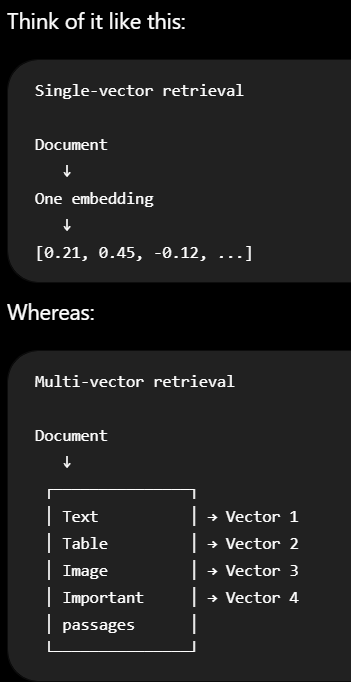

Ex: Hydraulic leakage inspection

Imagine a vector with 10 dimensions.

Dense vector: [0.021, -0.184, 0.073, 0.442, 0.118, -0.092, ...] # BGE-M3, the dense embedding has 1024 dimensions.

sparse vector: [0, 0, 0, 0.73, 0, 0, 0.44, 0, 0, 0]

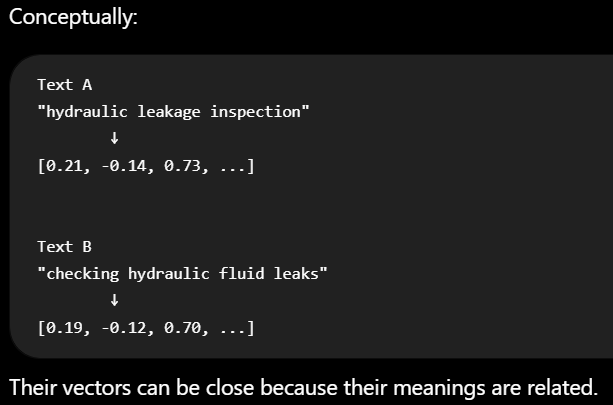

Single-vector  → one document → one vector

Multi-vector   → one document → many vectors

Hybrid Search      → combine two or more search technique to retrieve information.

```
                 User Query
                     |
          +----------+----------+
          |                     |
       BM25                  BGE-M3
     Sparse Search         Dense Search
          |                     |
     Exact words            Semantic meaning
          |                     |
          +----------+----------+
                     |
              Combine Results
                     |
                  Reranker
                     |
                Top Chunks
                     |
                    LLM
```

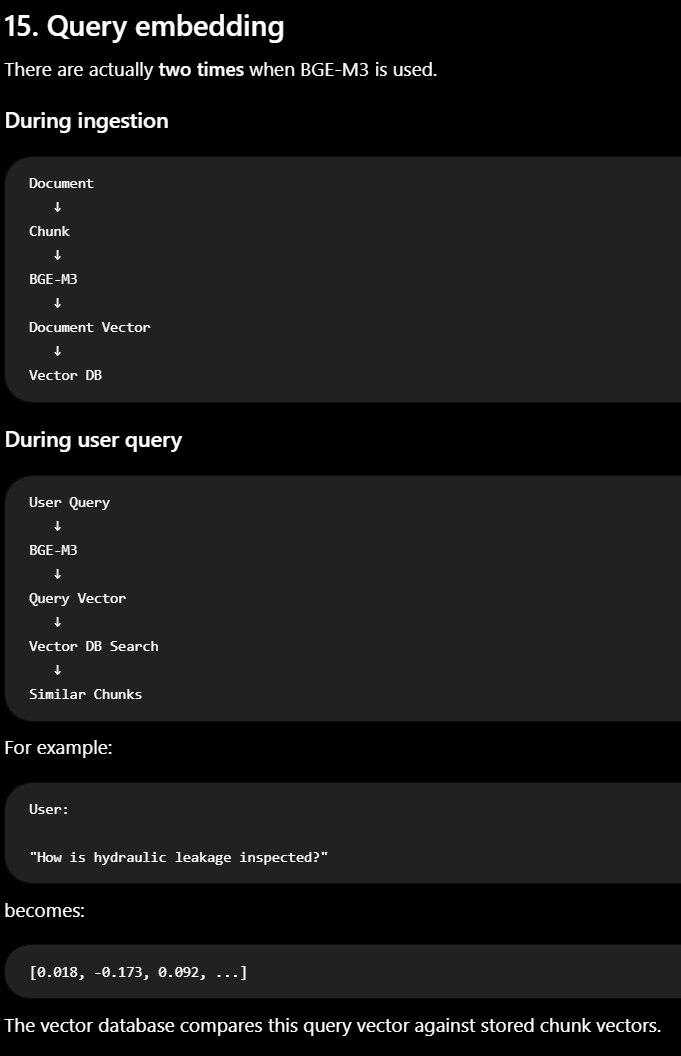


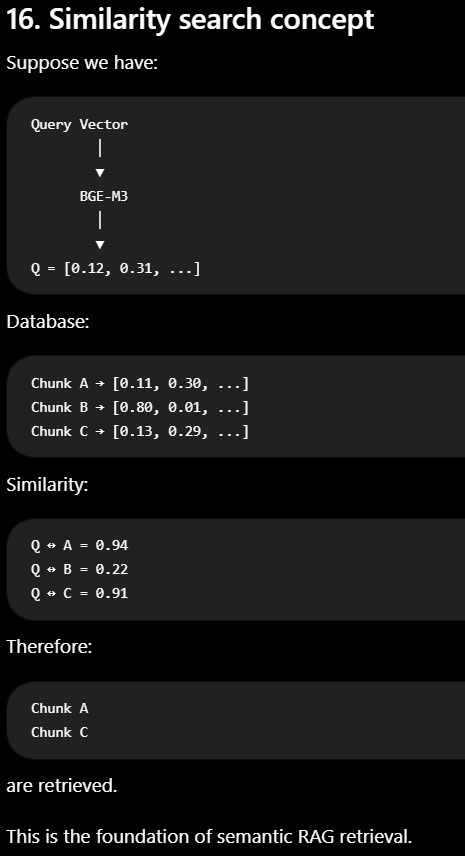

In [82]:
# Load BGE-M3
model = SentenceTransformer(
    "BAAI/bge-m3"
)

In [83]:
# Generate embeddings
def generate_embeddings(texts):

    embeddings = model.encode(
        texts,
        batch_size=4,
        normalize_embeddings=True,
        show_progress_bar=True
    )

    return embeddings

In [84]:
# Extract chunk text
chunk_texts = [chunk.page_content for chunk in all_chunks]
print("Texts to embed:",len(chunk_texts))

Texts to embed: 21


In [85]:
chunk_texts

['DOCUMENT TYPE: TECHNICAL BULLETIN\nDOCUMENT ID: TB-AVI-2026-002\nTITLE: Avionics Connector Inspection Advisory\nISSUE DATE: 2026-06-14\nAPPLICABLE AIRCRAFT: Aircraft-A\nSYSTEM: Avionics\nCLASSIFICATION: INTERNAL TRAINING DATA\n\nPURPOSE\nThis bulletin highlights recurring connector-related observations recorded during avionics maintenance.\n\nOBSERVATION\nSample maintenance reports indicate intermittent indications associated with connector condition and installation history.\n\nRECOMMENDED REVIEW\nReview applicable avionics maintenance procedures and maintenance history before performing component replacement. Record connector condition and relevant evidence in the maintenance record.\n\nDOCUMENT RELATION\nThe bulletin references MAN-AVI-A-003, Aircraft-A Avionics Maintenance Manual Rev-3.\n\nNOTE\nThis advisory does not replace the approved maintenance documentation.',
 'DOCUMENT TYPE: TECHNICAL BULLETIN\nDOCUMENT ID: TB-HYD-2026-001\nTITLE: Hydraulic System Leakage Inspection Advi

#### Generate embeddings

In [86]:
# Generate embeddings
embeddings = generate_embeddings(chunk_texts)
print("Embedding generation completed.")

Batches: 100%|██████████| 6/6 [00:06<00:00,  1.12s/it]

Embedding generation completed.


#### Verify embeddings

In [87]:
print("Number of embeddings:",len(embeddings))

print("Embedding dimension:",len(embeddings[0]))

Number of embeddings: 21
Embedding dimension: 1024


In [88]:
first_chunk = all_chunks[0]
first_chunk

Document(metadata={'document_type': 'TECHNICAL BULLETIN', 'document_id': 'TB-AVI-2026-002', 'title': 'Avionics Connector Inspection Advisory', 'issue_date': '2026-06-14', 'aircraft': 'Aircraft-A', 'system': 'Avionics', 'classification': 'INTERNAL TRAINING DATA', 'source_type': 'bulletins', 'source': '..\\drdo_rag_system\\data\\bulletins\\TECHNICAL_BULLETIN_AVIONICS_CONNECTOR_2026_002.txt', 'file_name': 'TECHNICAL_BULLETIN_AVIONICS_CONNECTOR_2026_002.txt', 'folder': 'bulletins', 'section': 'General', 'chunk_id': 'TB-AVI-2026-002_chunk_0000', 'chunk_size': 860}, page_content='DOCUMENT TYPE: TECHNICAL BULLETIN\nDOCUMENT ID: TB-AVI-2026-002\nTITLE: Avionics Connector Inspection Advisory\nISSUE DATE: 2026-06-14\nAPPLICABLE AIRCRAFT: Aircraft-A\nSYSTEM: Avionics\nCLASSIFICATION: INTERNAL TRAINING DATA\n\nPURPOSE\nThis bulletin highlights recurring connector-related observations recorded during avionics maintenance.\n\nOBSERVATION\nSample maintenance reports indicate intermittent indications 

In [89]:
print("Chunk ID:",first_chunk.metadata["chunk_id"])
print("Document ID:",first_chunk.metadata.get("document_id"))
print("System:",first_chunk.metadata.get("system"))
print("Section:",first_chunk.metadata.get("section"))


Chunk ID: TB-AVI-2026-002_chunk_0000
Document ID: TB-AVI-2026-002
System: Avionics
Section: General


In [90]:
print("TEXT:", first_chunk.page_content)

TEXT: DOCUMENT TYPE: TECHNICAL BULLETIN
DOCUMENT ID: TB-AVI-2026-002
TITLE: Avionics Connector Inspection Advisory
ISSUE DATE: 2026-06-14
APPLICABLE AIRCRAFT: Aircraft-A
SYSTEM: Avionics
CLASSIFICATION: INTERNAL TRAINING DATA

PURPOSE
This bulletin highlights recurring connector-related observations recorded during avionics maintenance.

OBSERVATION
Sample maintenance reports indicate intermittent indications associated with connector condition and installation history.

RECOMMENDED REVIEW
Review applicable avionics maintenance procedures and maintenance history before performing component replacement. Record connector condition and relevant evidence in the maintenance record.

DOCUMENT RELATION
The bulletin references MAN-AVI-A-003, Aircraft-A Avionics Maintenance Manual Rev-3.

NOTE
This advisory does not replace the approved maintenance documentation.


In [91]:
print(embeddings[0])

[-0.03874877 -0.00313961 -0.07221105 ...  0.03028087  0.02689066
  0.0249529 ]


In [92]:
chunk_texts = [chunk.page_content for chunk in all_chunks]
chunk_texts

['DOCUMENT TYPE: TECHNICAL BULLETIN\nDOCUMENT ID: TB-AVI-2026-002\nTITLE: Avionics Connector Inspection Advisory\nISSUE DATE: 2026-06-14\nAPPLICABLE AIRCRAFT: Aircraft-A\nSYSTEM: Avionics\nCLASSIFICATION: INTERNAL TRAINING DATA\n\nPURPOSE\nThis bulletin highlights recurring connector-related observations recorded during avionics maintenance.\n\nOBSERVATION\nSample maintenance reports indicate intermittent indications associated with connector condition and installation history.\n\nRECOMMENDED REVIEW\nReview applicable avionics maintenance procedures and maintenance history before performing component replacement. Record connector condition and relevant evidence in the maintenance record.\n\nDOCUMENT RELATION\nThe bulletin references MAN-AVI-A-003, Aircraft-A Avionics Maintenance Manual Rev-3.\n\nNOTE\nThis advisory does not replace the approved maintenance documentation.',
 'DOCUMENT TYPE: TECHNICAL BULLETIN\nDOCUMENT ID: TB-HYD-2026-001\nTITLE: Hydraulic System Leakage Inspection Advi

In [93]:
# !pip install qdrant-client

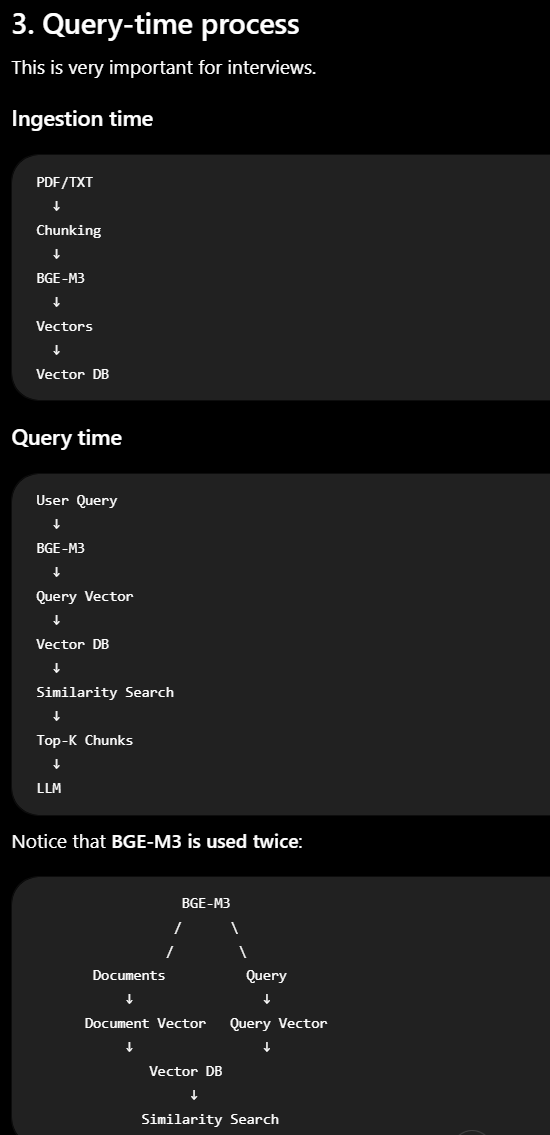

In [94]:
import os
from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance

qdrant_client = QdrantClient(
    url=os.environ["QDRANT_URL"],
    api_key=os.environ["QDRANT_API_KEY"],
)

print(qdrant_client.get_collections())

C:\Users\rootl\AppData\Local\Temp\ipykernel_23784\3205489230.py:5: UserWarning: Qdrant client version 1.16.1 is incompatible with server version 1.19.1. Major versions should match and minor version difference must not exceed 1. Set check_compatibility=False to skip version check.
  qdrant_client = QdrantClient(


collections=[CollectionDescription(name='defence_aerospace_rag')]


In [95]:
collection_name = "defence_aerospace_rag"
vector_size = 1024

#### Connect to Qdrant Cloud

In [96]:
collections = qdrant_client.get_collections()

existing_collections = [
    collection.name
    for collection in collections.collections
]


if collection_name not in existing_collections:

    qdrant_client.create_collection(
        collection_name=collection_name,
        vectors_config=VectorParams(
            size=vector_size,
            distance=Distance.COSINE
        )
    )

    print("Collection created")

else:

    print("Collection already exists")

Collection already exists


####  Upload Chunks + Embeddings

In [97]:
points = []

for index, chunk in enumerate(all_chunks):

    points.append(
        PointStruct(
            id=index,

            vector=embeddings[index].tolist(),

            payload={
                "text": chunk.page_content,
                **chunk.metadata
            }
        )
    )


qdrant_client.upsert(
    collection_name=collection_name,
    points=points
)

print(f"Uploaded {len(points)} chunks")

ResponseHandlingException: The write operation timed out

#### Verify

In [ ]:
collection_info = qdrant_client.get_collection(
    collection_name
)

print(collection_info)

status=<CollectionStatus.GREEN: 'green'> optimizer_status=<OptimizersStatusOneOf.OK: 'ok'> warnings=None indexed_vectors_count=0 points_count=21 segments_count=2 config=CollectionConfig(params=CollectionParams(vectors=VectorParams(size=1024, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, datatype=None, multivector_config=None), shard_number=1, sharding_method=None, replication_factor=1, write_consistency_factor=1, read_fan_out_factor=None, on_disk_payload=True, sparse_vectors=None), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=False, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=10000, flush_interval_sec=5, max_optimization_threads=None), wal_config=WalConfig(wal_capacity_mb=32, wal_segments_ahead=0, wal_retai

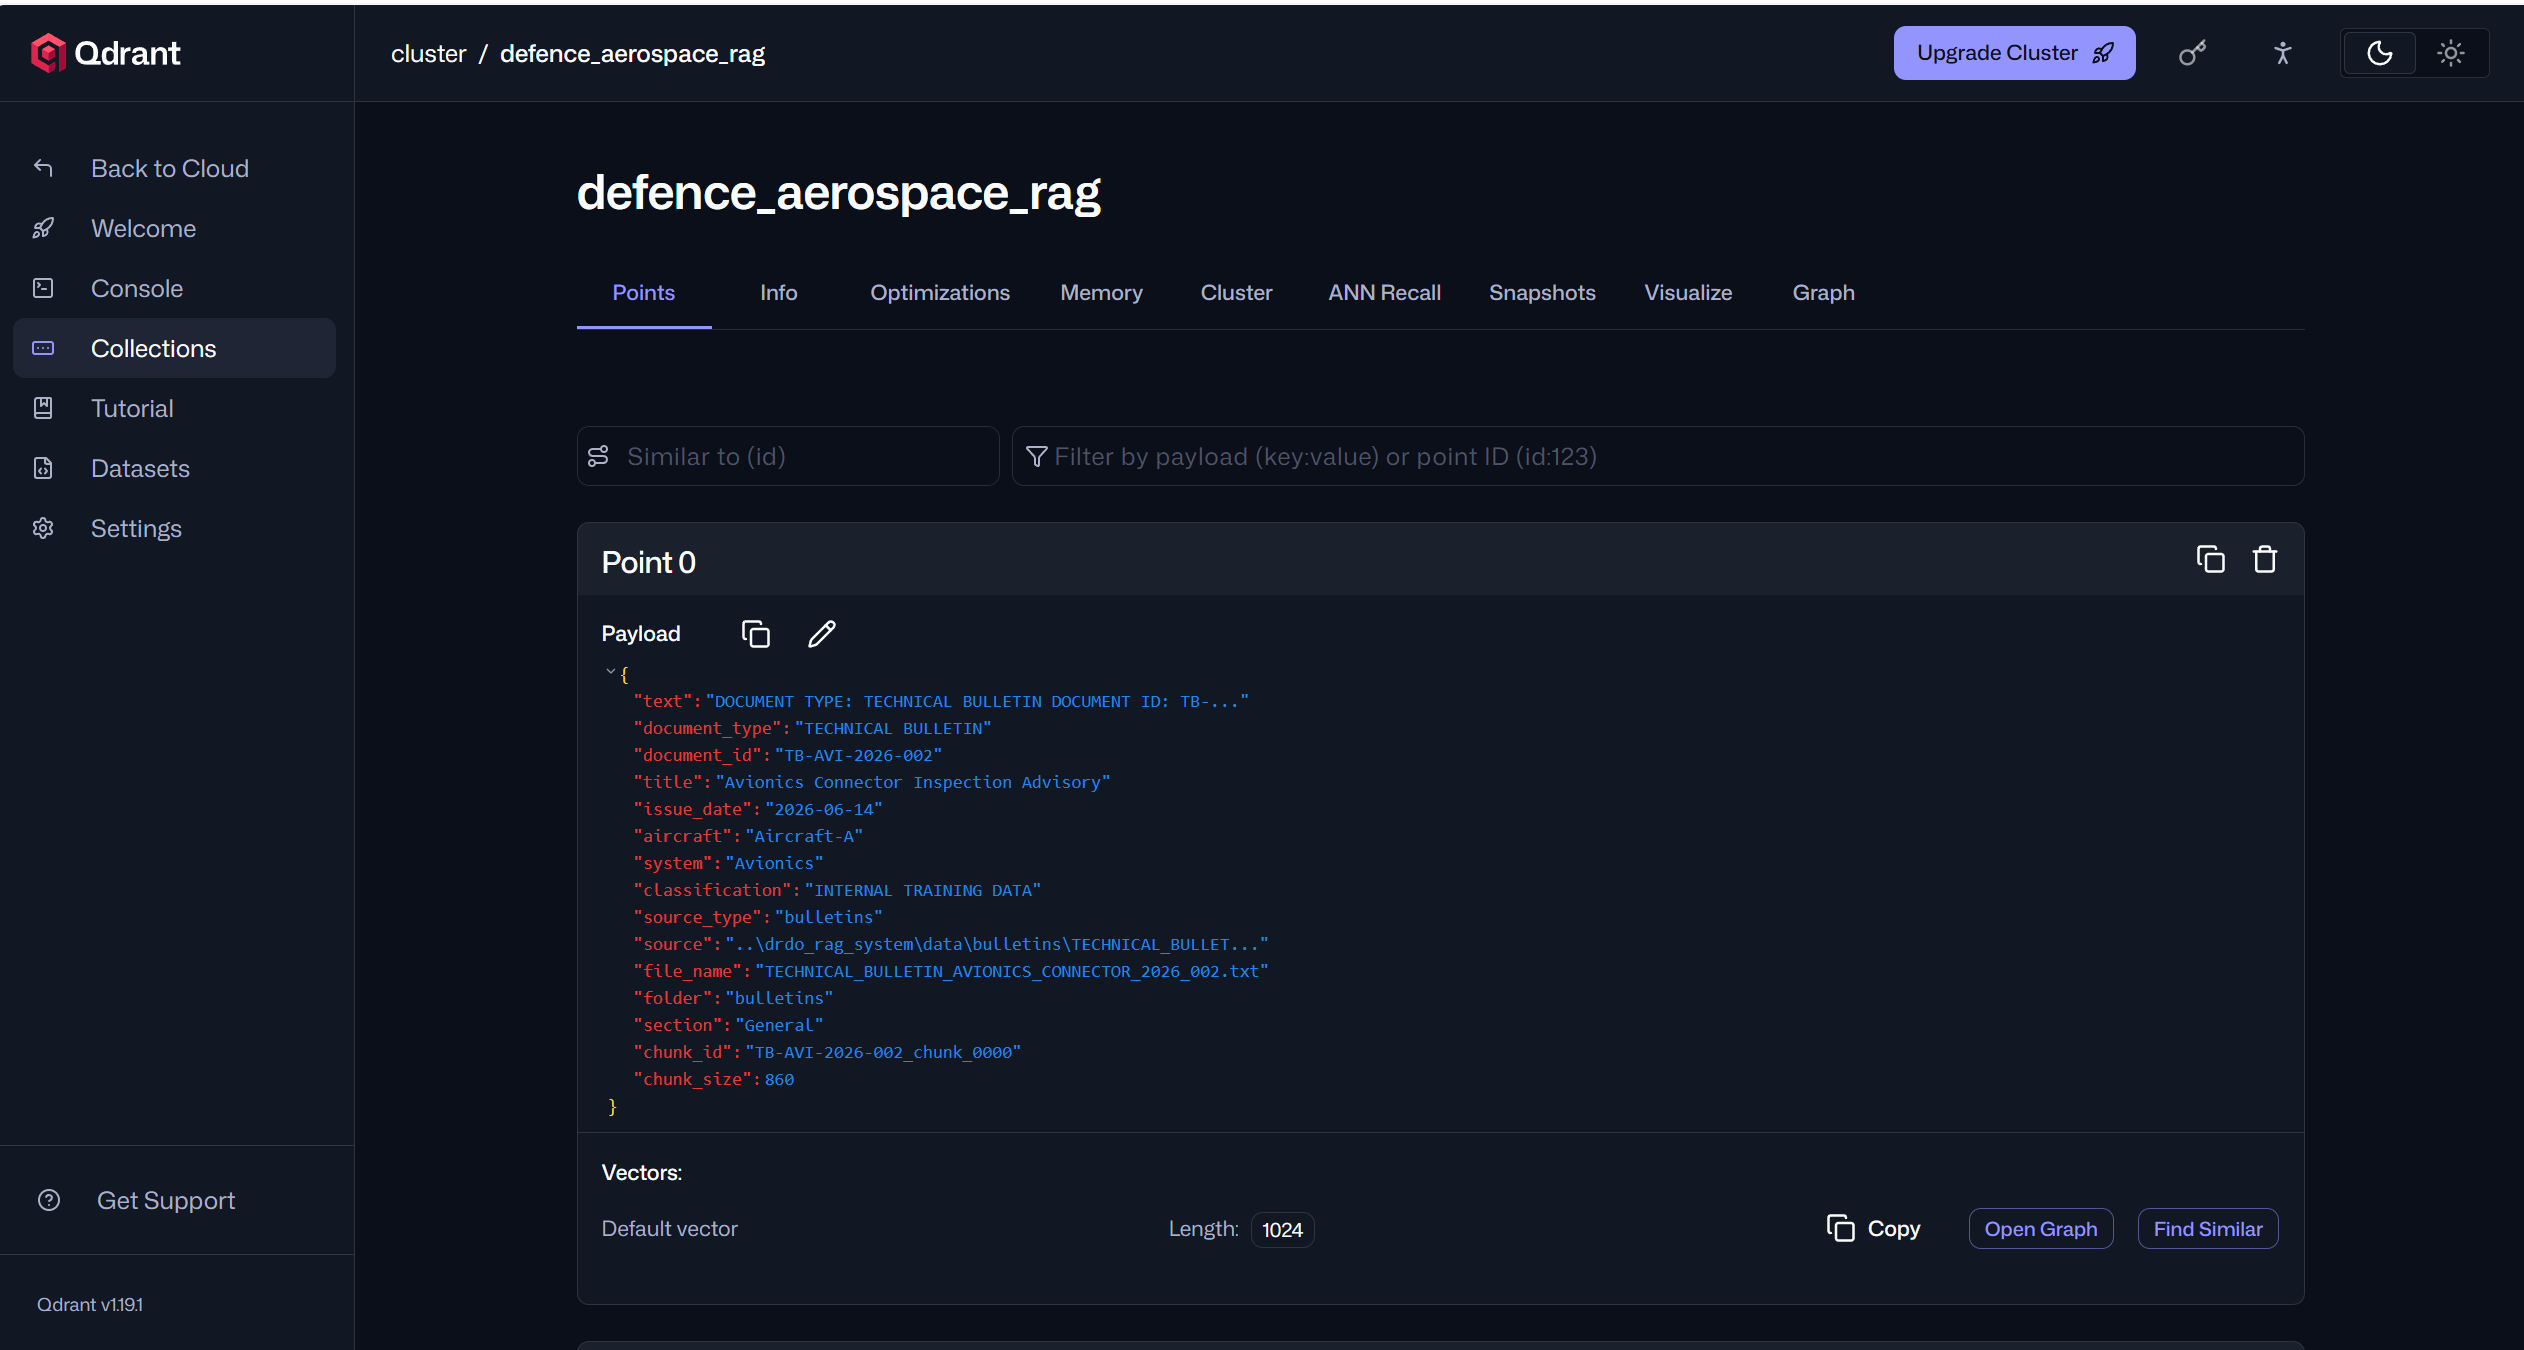

In [ ]:
# data = [
#     {
#         'Name': 'John',
#         'Details': {
#             'Age': 30,
#             'Gender': 'M',
#             'Employed': 0
#         }
#     },
#     {
#         'Name': 'Jane',
#         'Details': {
#             'Age': 28,
#             'Gender': 'F',
#             'Employed': 1,
#             'Employer': 'Umbrella Corporation'
#         }
#     }
# ]

#### Step 6 -> ElasticSearch Hybrid Search

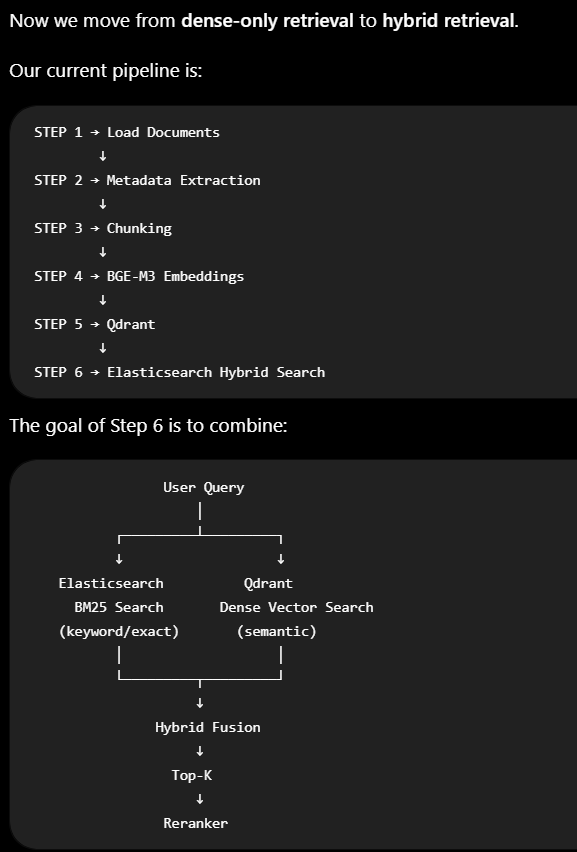

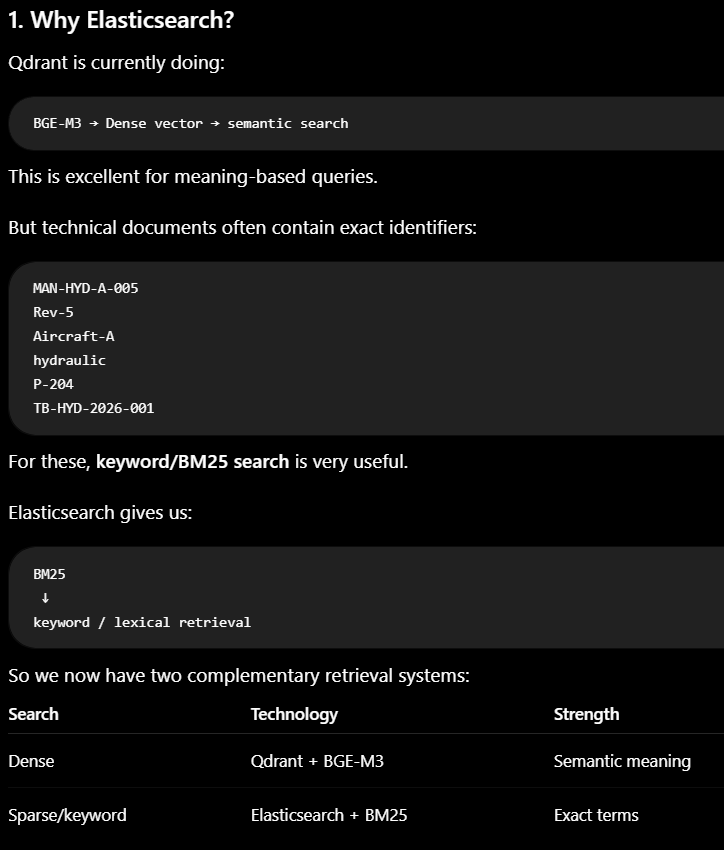

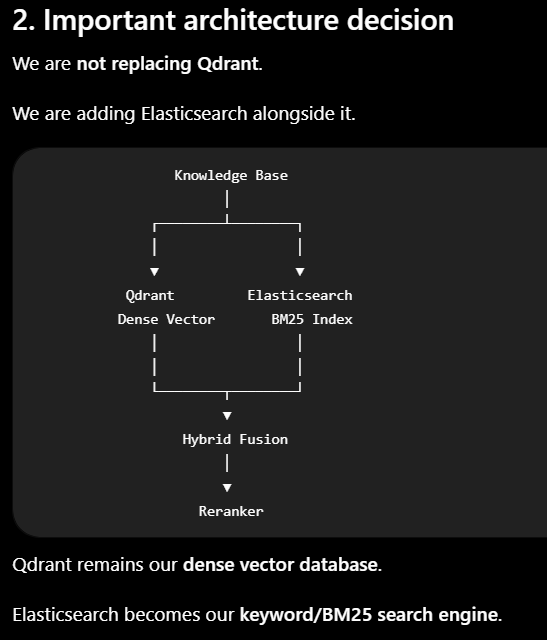

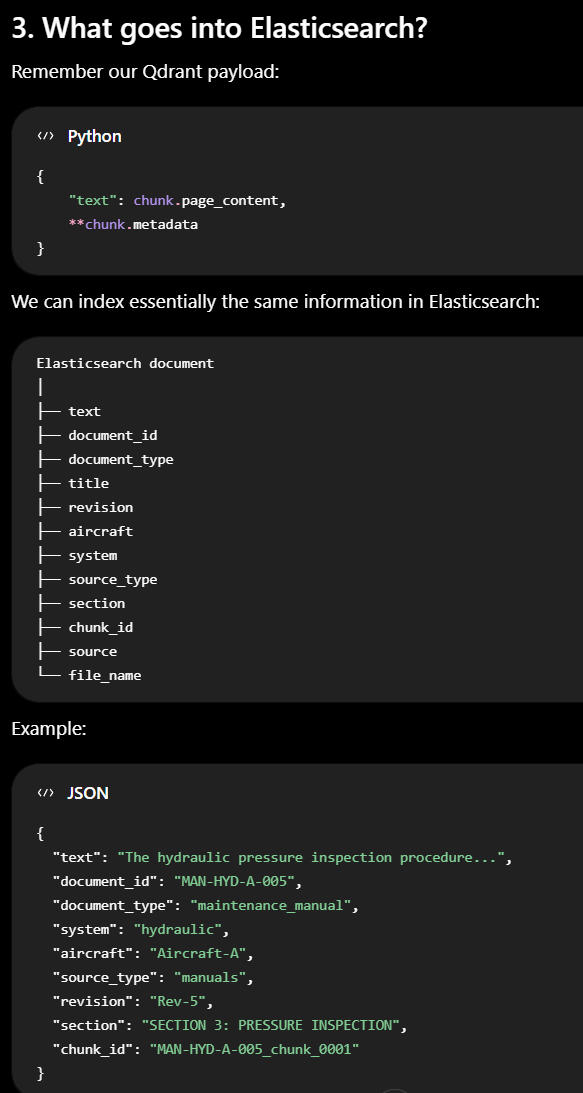

In [ ]:
# !pip install elasticsearch

In [ ]:
import os
from dotenv import load_dotenv
from elasticsearch import Elasticsearch

load_dotenv()

ELASTICSEARCH_URL = os.getenv("ELASTICSEARCH_URL")
ELASTICSEARCH_API_KEY = os.getenv("ELASTICSEARCH_API_KEY")

es = Elasticsearch(
    ELASTICSEARCH_URL,
    api_key=ELASTICSEARCH_API_KEY
)

try:
    print(es.info())
except Exception as e:
    print("INFO ERROR:", repr(e))

{'name': 'serverless', 'cluster_name': 'd2de9371898e40369f093d4132539bf1', 'cluster_uuid': 'XtNUfGNAQ4y3GEd_nYKvAw', 'version': {'number': '9.6.0', 'build_flavor': 'serverless', 'build_type': 'docker', 'build_hash': '2b92f3f9b5a011ed77c1525509d4a03233625ba2', 'build_date': '2026-09-21T09:51:34.294563299Z', 'build_snapshot': False, 'lucene_version': '10.5.1', 'minimum_wire_compatibility_version': '9.6.0', 'minimum_index_compatibility_version': '9.6.0'}, 'tagline': 'You Know, for Search'}


In [ ]:
print(es.ping())

True


Better test for your project

Since we're going to create an index anyway, test an actual API operation:

In [ ]:
try:
    response = es.indices.exists(
        index="defence_aerospace_rag"
    )

    print("Elasticsearch connection is working")
    print("Index exists:", response)

except Exception as e:
    print("Elasticsearch ERROR:")
    print(type(e).__name__)
    print(e)

Elasticsearch connection is working
Index exists: True


#### 6.2 — Create the index

In [ ]:
INDEX_NAME = "defence_aerospace_rag"

if not es.indices.exists(index=INDEX_NAME):

    es.indices.create(
        index=INDEX_NAME,
        mappings={
            "properties": {
                "text": {
                    "type": "text"
                },
                "document_id": {
                    "type": "keyword"
                },
                "document_type": {
                    "type": "keyword"
                },
                "title": {
                    "type": "text"
                },
                "revision": {
                    "type": "keyword"
                },
                "aircraft": {
                    "type": "keyword"
                },
                "system": {
                    "type": "keyword"
                },
                "source_type": {
                    "type": "keyword"
                },
                "section": {
                    "type": "text"
                },
                "chunk_id": {
                    "type": "keyword"
                },
                "source": {
                    "type": "keyword"
                },
                "file_name": {
                    "type": "keyword"
                }
            }
        }
    )

    print("Index created:", INDEX_NAME)

else:

    print("Index already exists:", INDEX_NAME)

Index already exists: defence_aerospace_rag


In [ ]:
print(es.indices.get(index=INDEX_NAME))

{'defence_aerospace_rag': {'aliases': {}, 'mappings': {'properties': {'aircraft': {'type': 'keyword'}, 'category': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'chunk_id': {'type': 'keyword'}, 'chunk_size': {'type': 'long'}, 'classification': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'document_id': {'type': 'keyword'}, 'document_type': {'type': 'keyword'}, 'effective_date': {'type': 'date'}, 'file_name': {'type': 'keyword'}, 'folder': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'issue_date': {'type': 'date'}, 'report_date': {'type': 'date'}, 'report_id': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'reporting_period': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'revision': {'type': 'keyword'}, 'section': {'type': 'text'}, 'severity': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'i

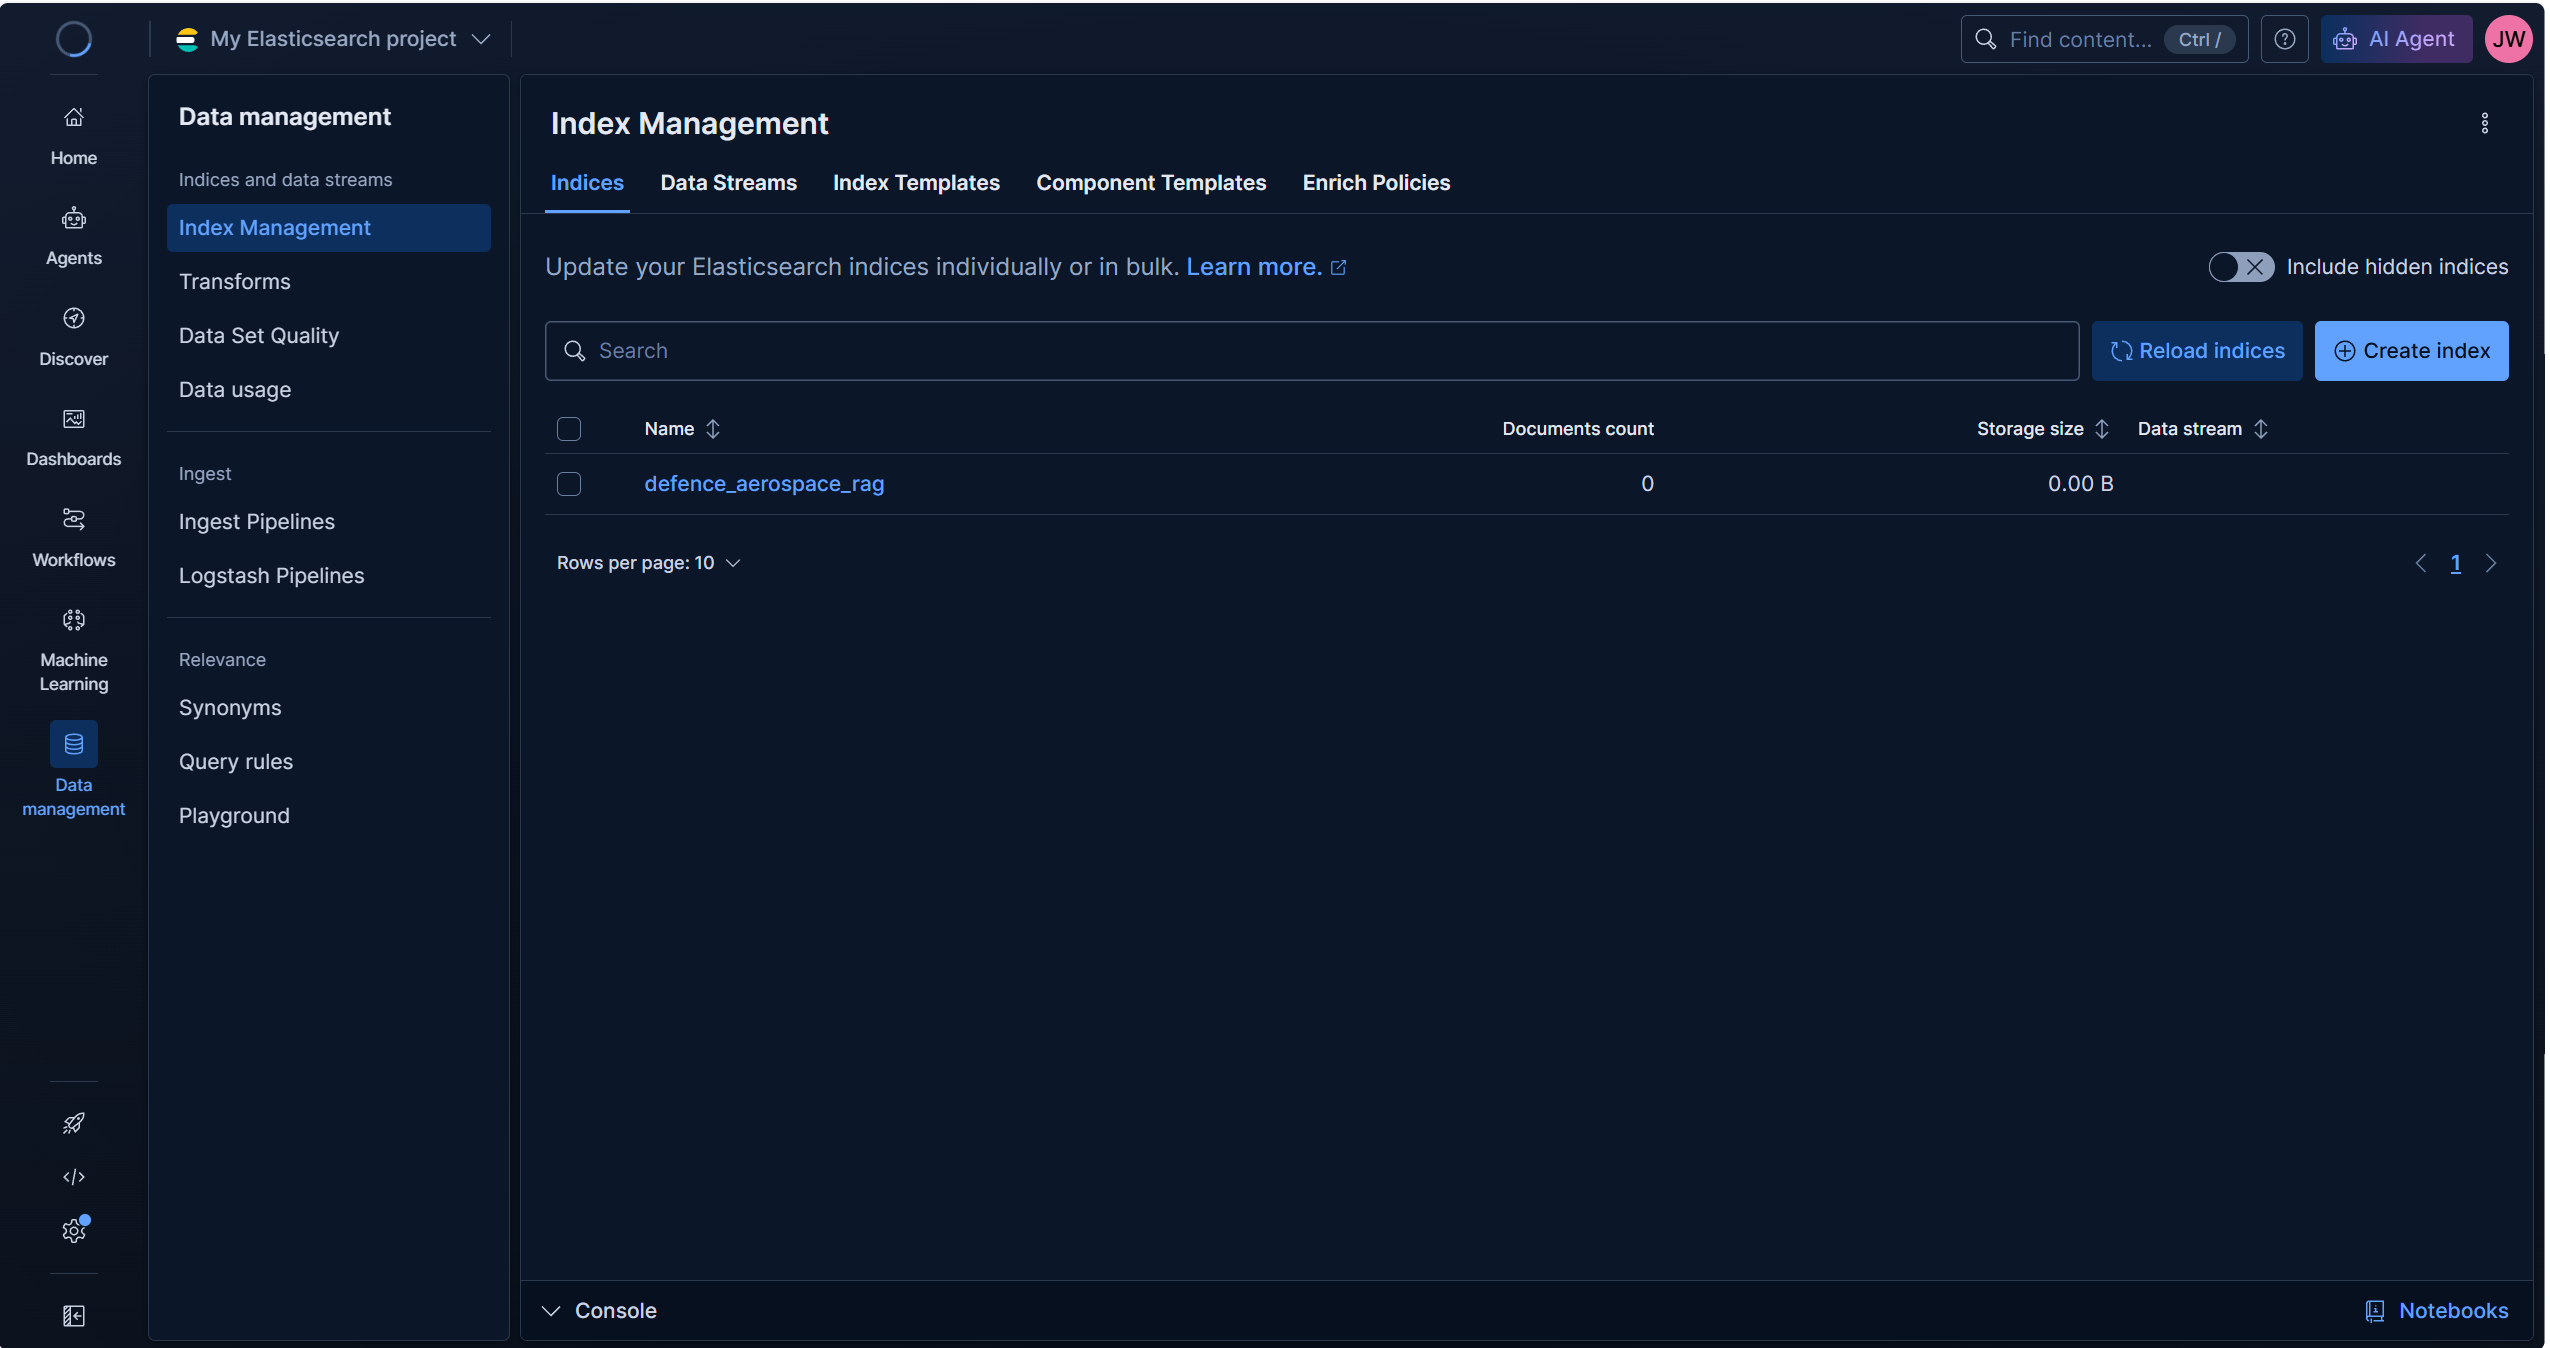

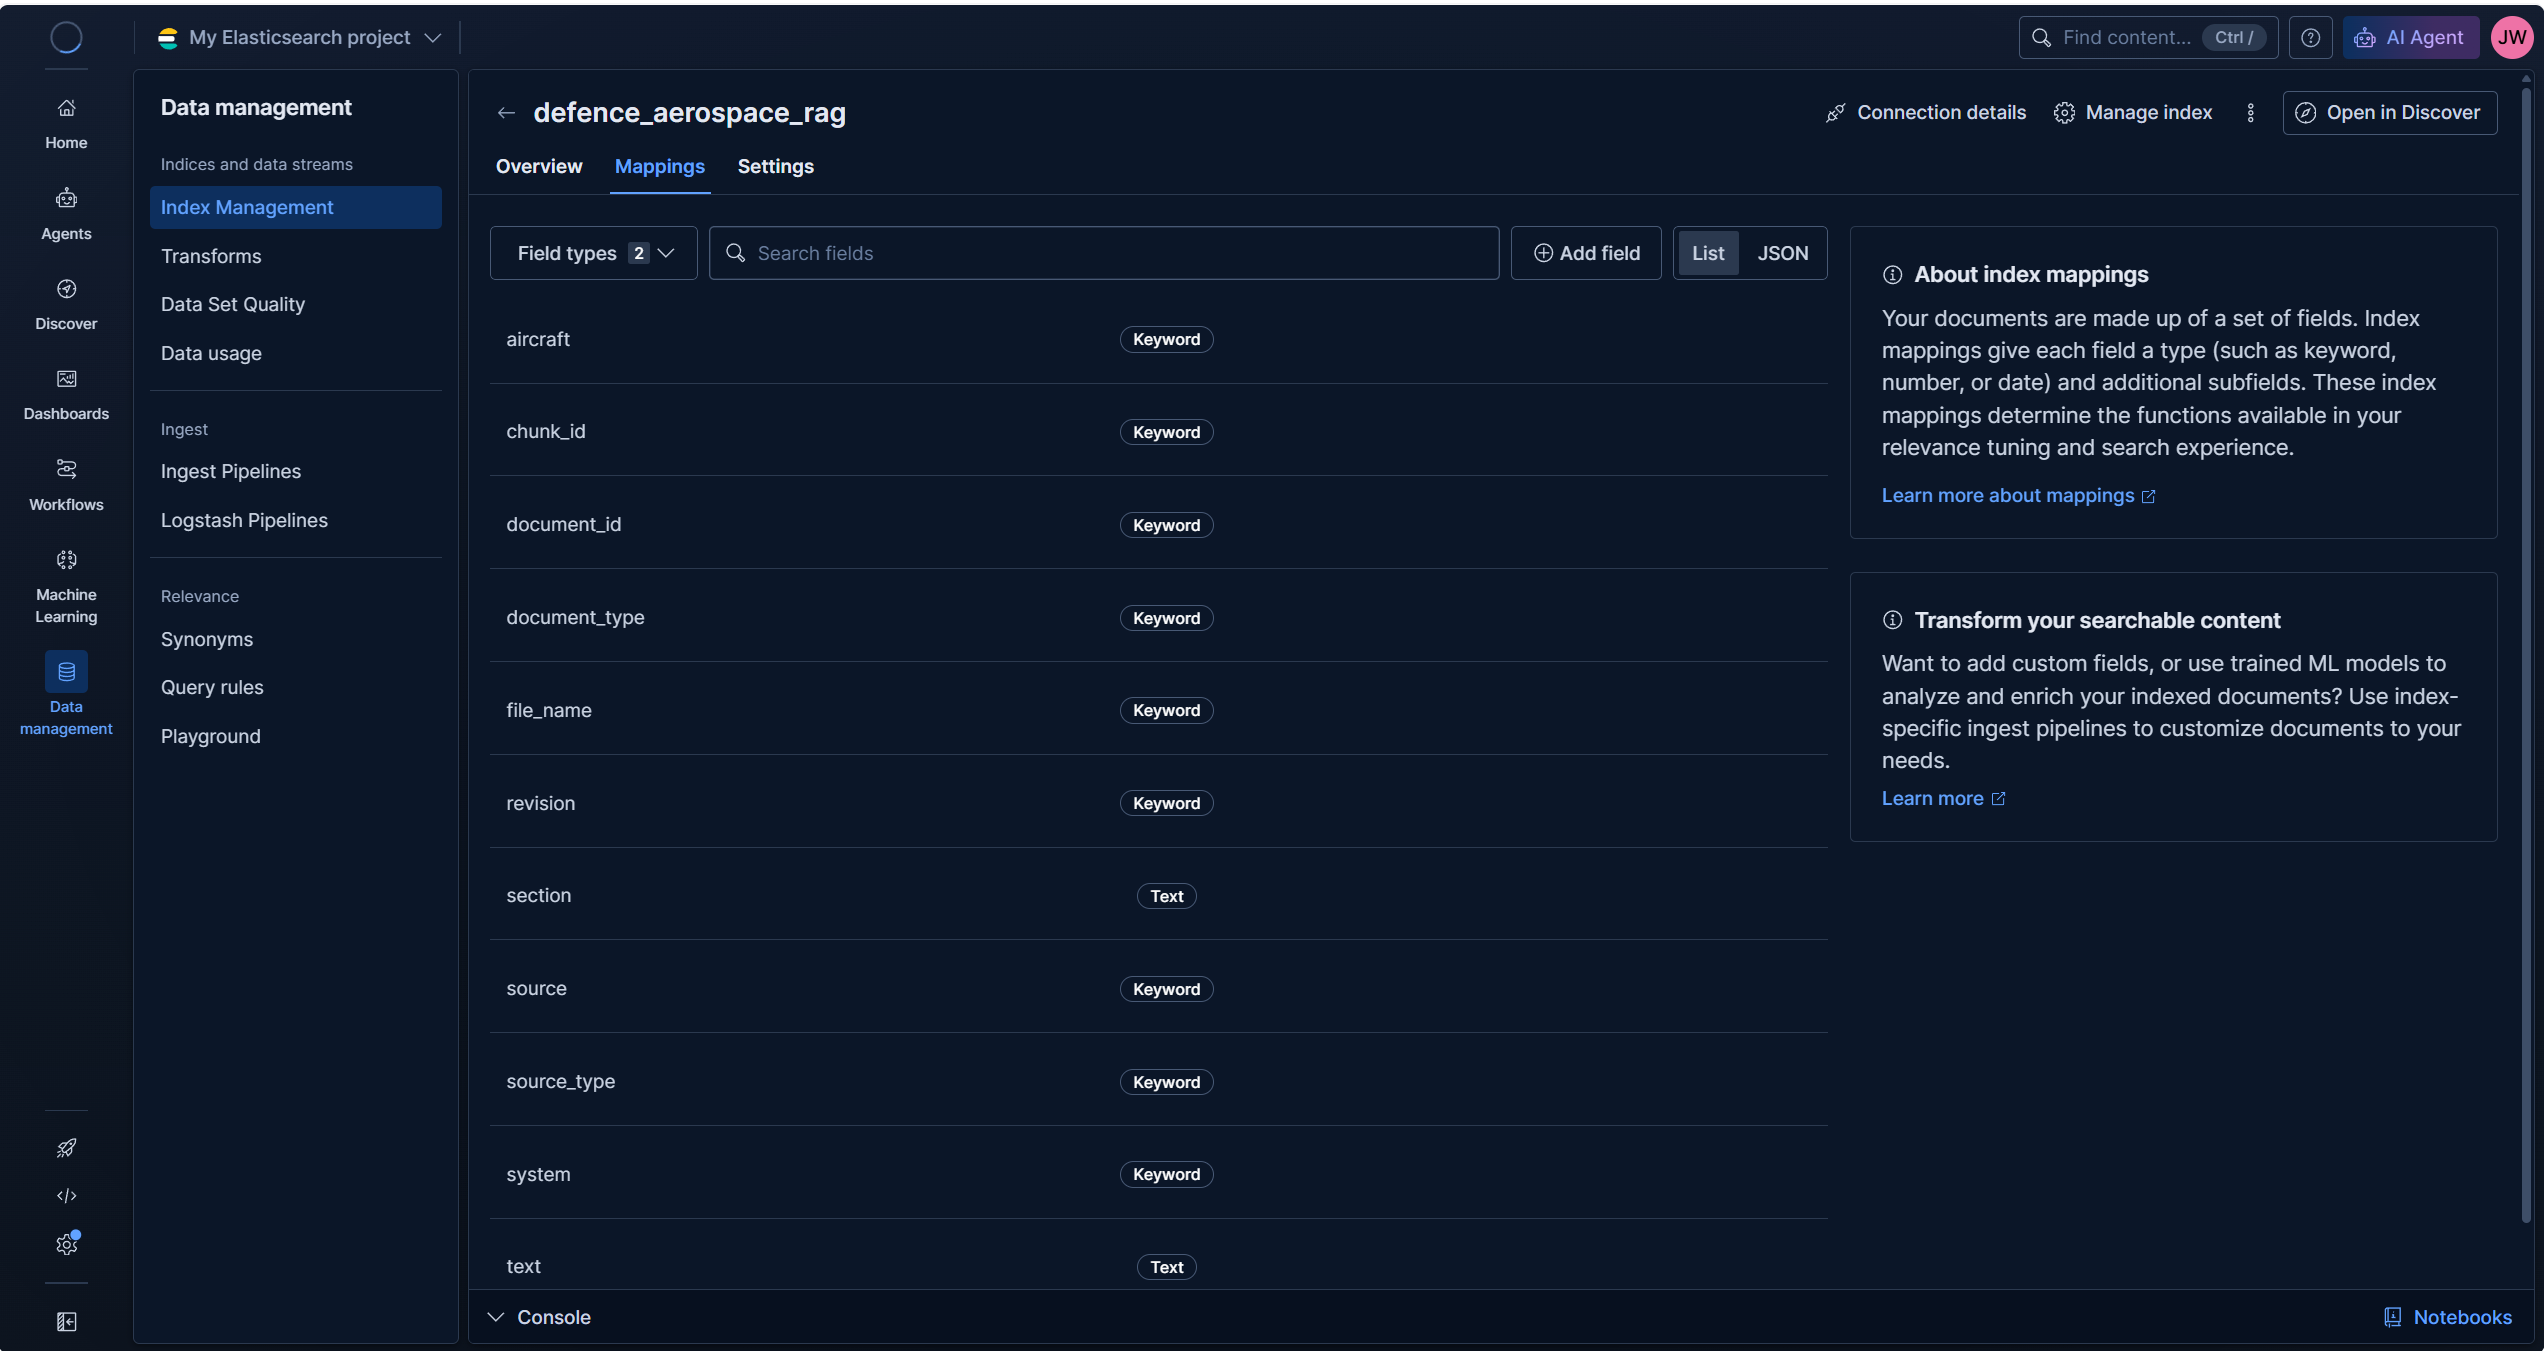

#### 6.4 — Upload your chunks

In [ ]:
from elasticsearch.helpers import bulk

actions = []

for chunk in all_chunks:

    actions.append({
        "_index": INDEX_NAME,
        "_id": chunk.metadata["chunk_id"],
        "_source": {
            "text": chunk.page_content,
            **chunk.metadata
        }
    })

result = bulk(es, actions)

print("Upload completed")
print("Chunks uploaded:", len(actions))

Upload completed
Chunks uploaded: 21


In [ ]:
print(bulk(es, actions))

(21, [])


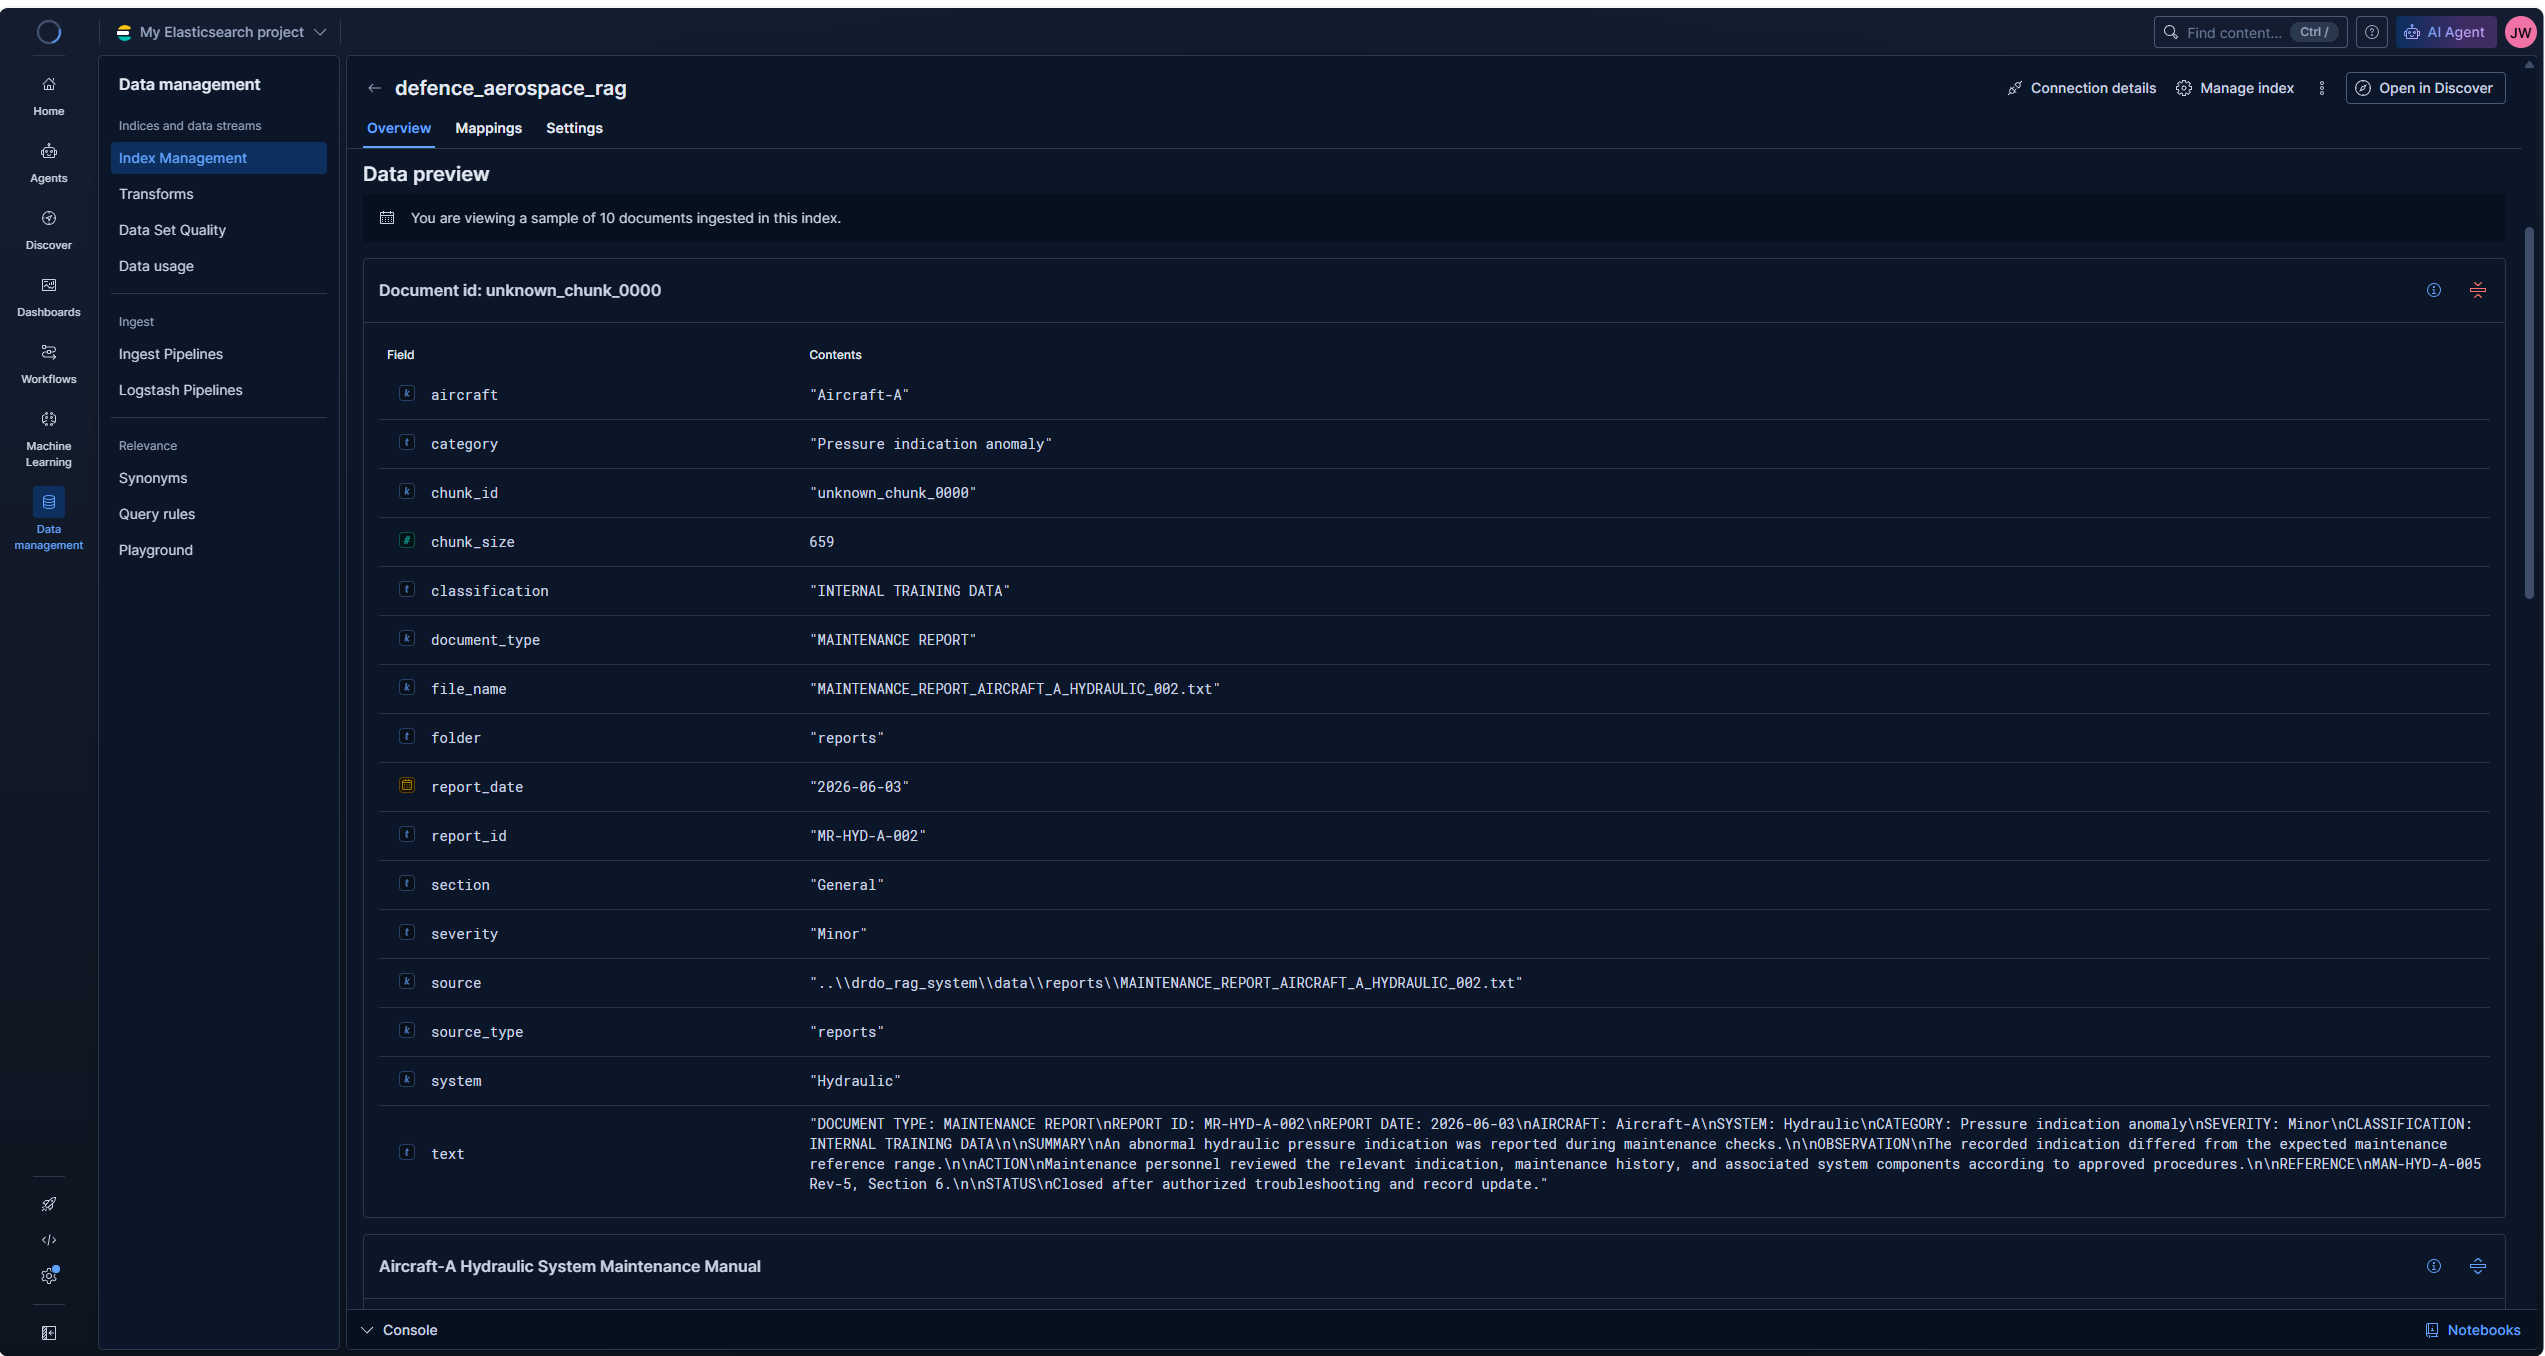

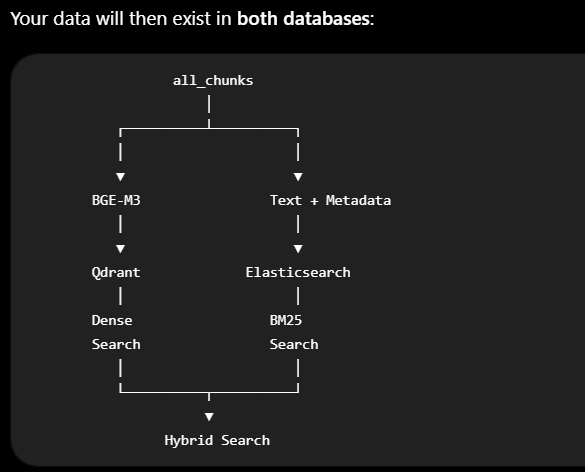

#### 6.5 → Test BM25 Search

In [ ]:
query = "What is the hydraulic pressure inspection procedure?"

In [ ]:
response = es.search(
    index=INDEX_NAME,
    query={
        "match": {
            "text": query
        }
    },
    size=5
)

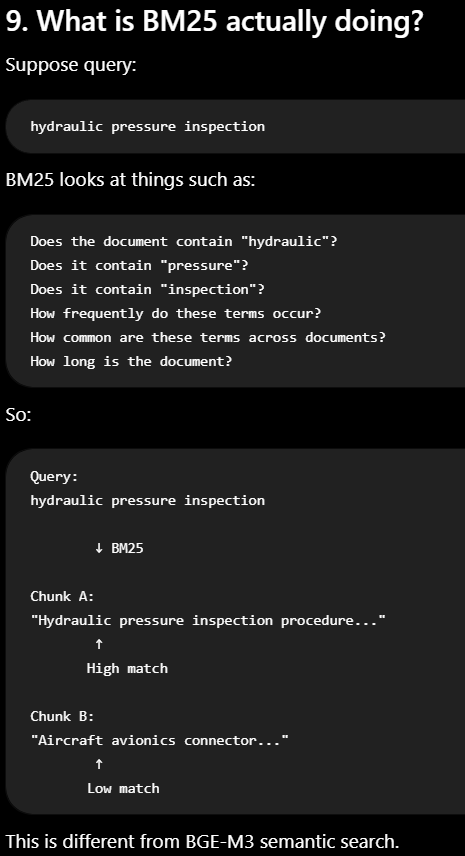

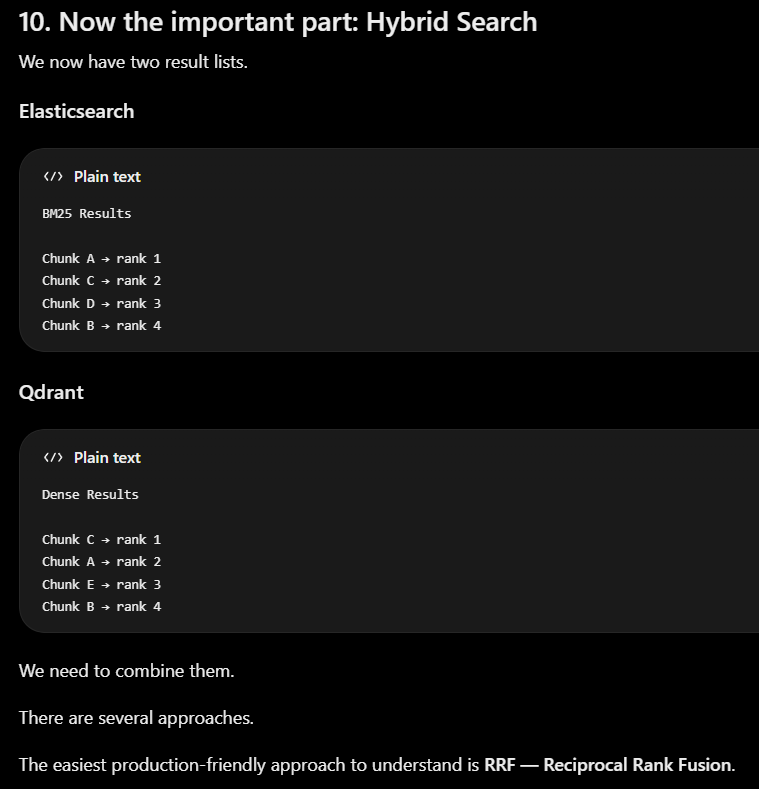

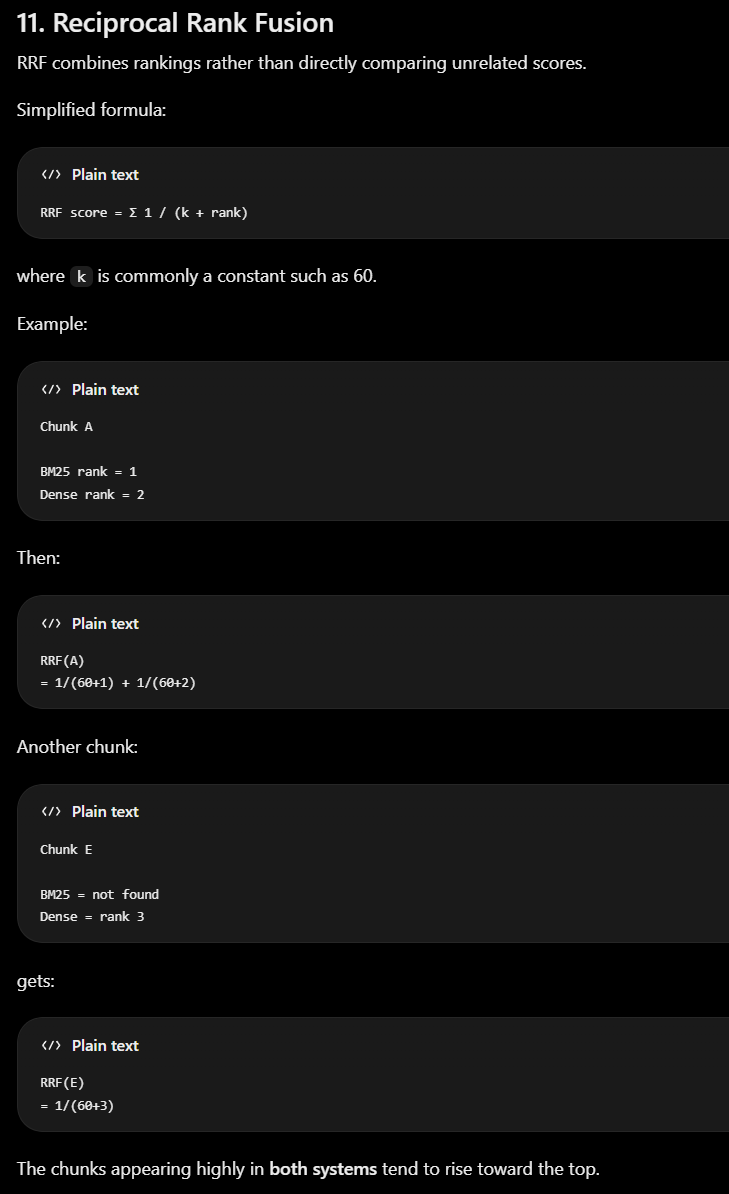



**Score - BM25**

Score: 2.7917085

Score: 2.5537739

Score: 1.7617857

Score: 1.3597229

Score: 1.2998557

In [ ]:
for hit in response["hits"]["hits"]:

    print("Score:", hit["_score"])
    print("Chunk:", hit["_source"]["chunk_id"])
    print("Text:", hit["_source"]["text"])
    print("-" * 80)

Score: 4.039283
Chunk: MAN-HYD-A-005_chunk_0002
Text: Before inspection, place the aircraft in the approved maintenance configuration. Isolate the hydraulic subsystem according to the applicable maintenance procedure. Verify that stored hydraulic pressure has been safely relieved before opening any connection. Use approved personal protective equipment and the organization's maintenance safety checklist.
--------------------------------------------------------------------------------
Score: 3.6271882
Chunk: unknown_chunk_0000
Text: DOCUMENT TYPE: MAINTENANCE REPORT
REPORT ID: MR-HYD-A-002
REPORT DATE: 2026-06-03
AIRCRAFT: Aircraft-A
SYSTEM: Hydraulic
CATEGORY: Pressure indication anomaly
SEVERITY: Minor
CLASSIFICATION: INTERNAL TRAINING DATA

SUMMARY
An abnormal hydraulic pressure indication was reported during maintenance checks.

OBSERVATION
The recorded indication differed from the expected maintenance reference range.

ACTION
Maintenance personnel reviewed the relevant indication, 

### Understanding Hybrid Search/RAG behind the scenes mathematically

```
User Question
      │
      ├───────────────┐
      ↓               ↓
   BM25            BGE-M3
 Elasticsearch      Dense
      ↓               ↓
 BM25 ranking      Vector ranking
      │               │
      └───────┬───────┘
              ↓
             RRF
              ↓
        Combined Ranking
              ↓
          Reranker
              ↓
        Best 3–5 chunks
              ↓
             LLM
              ↓
       Grounded Answer
```

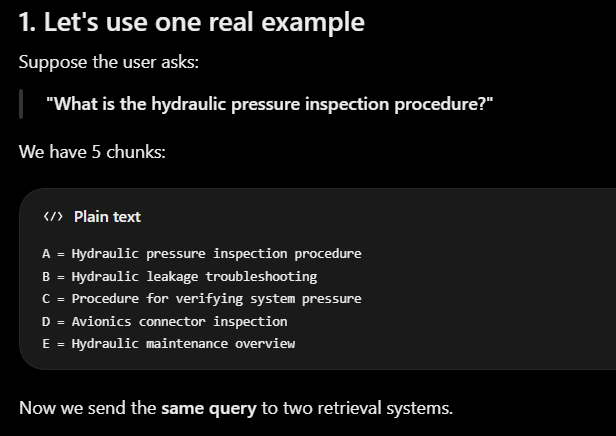

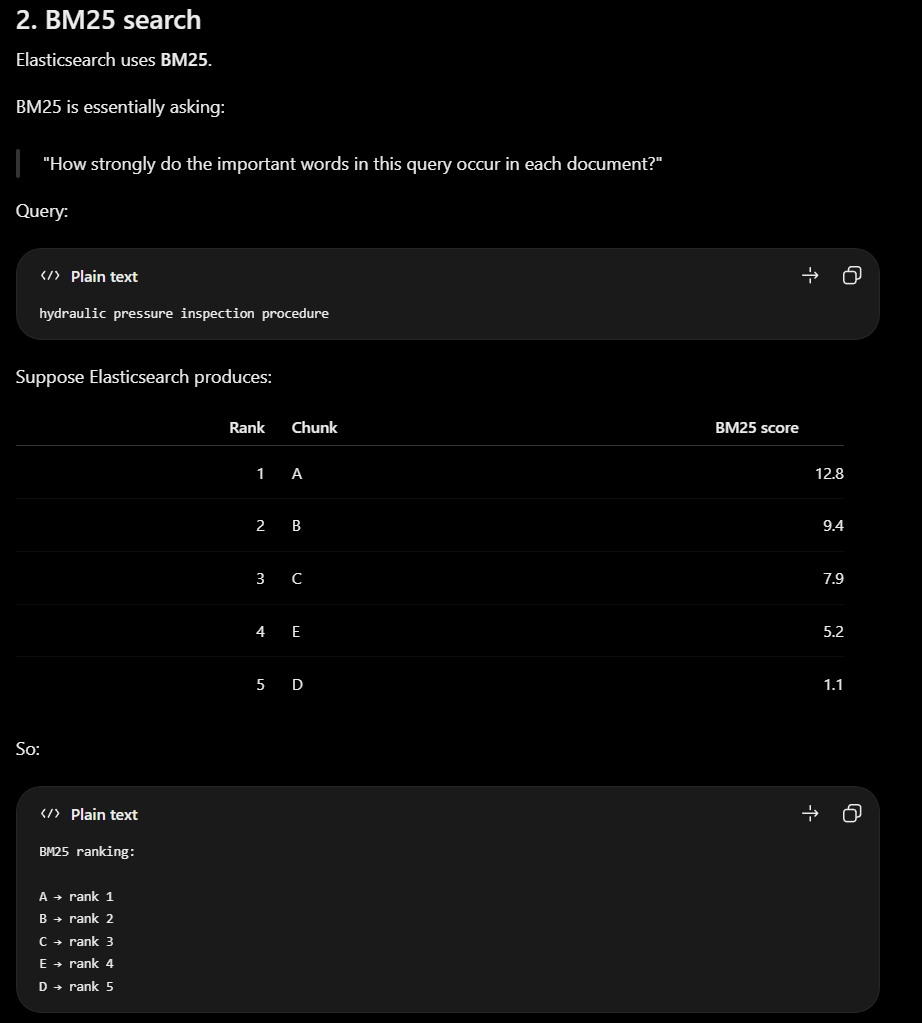

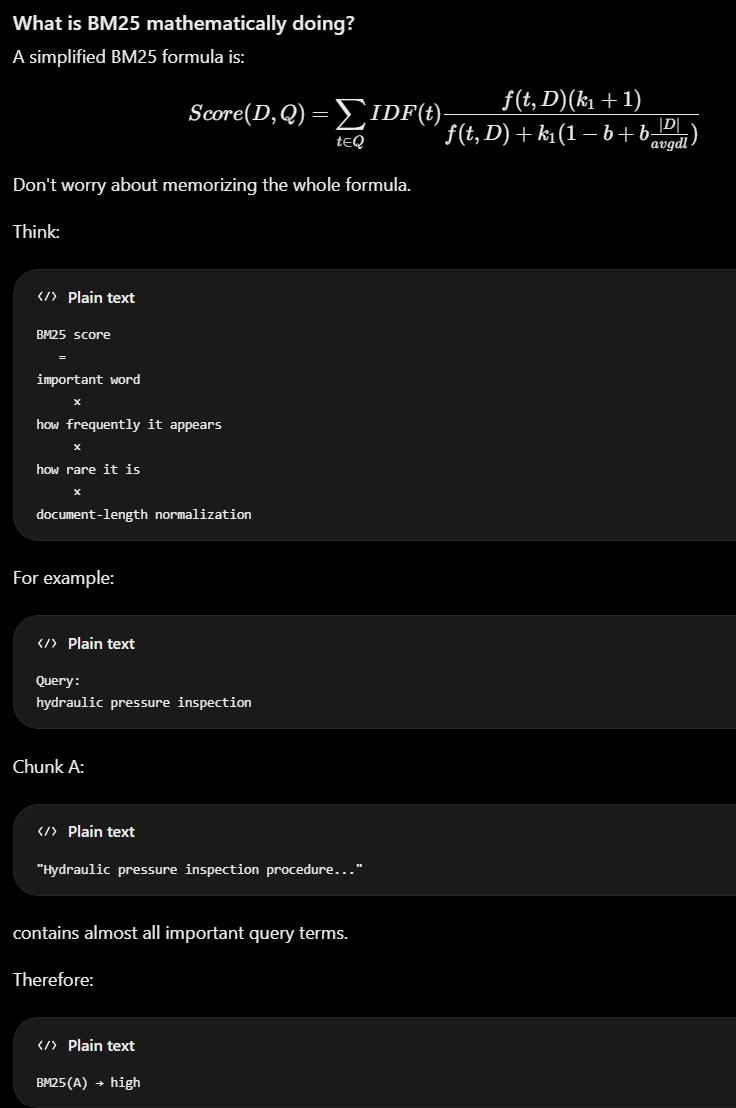

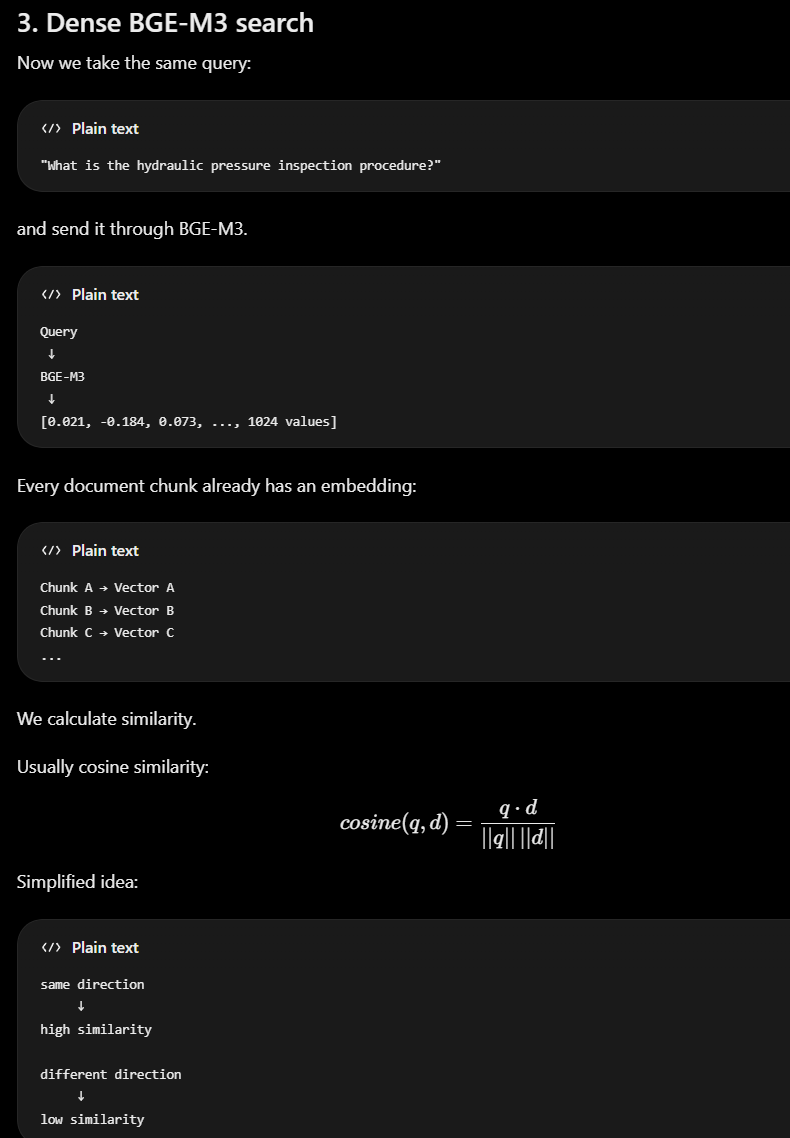

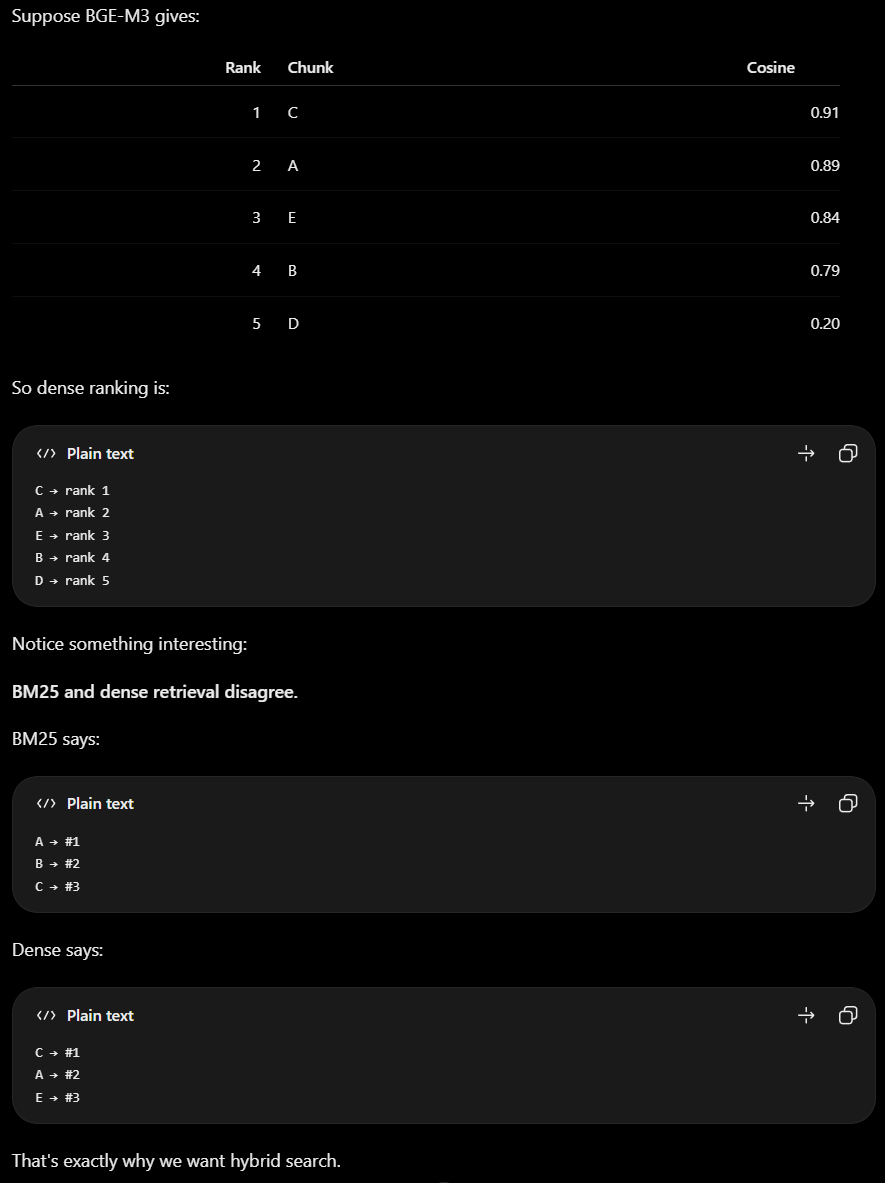

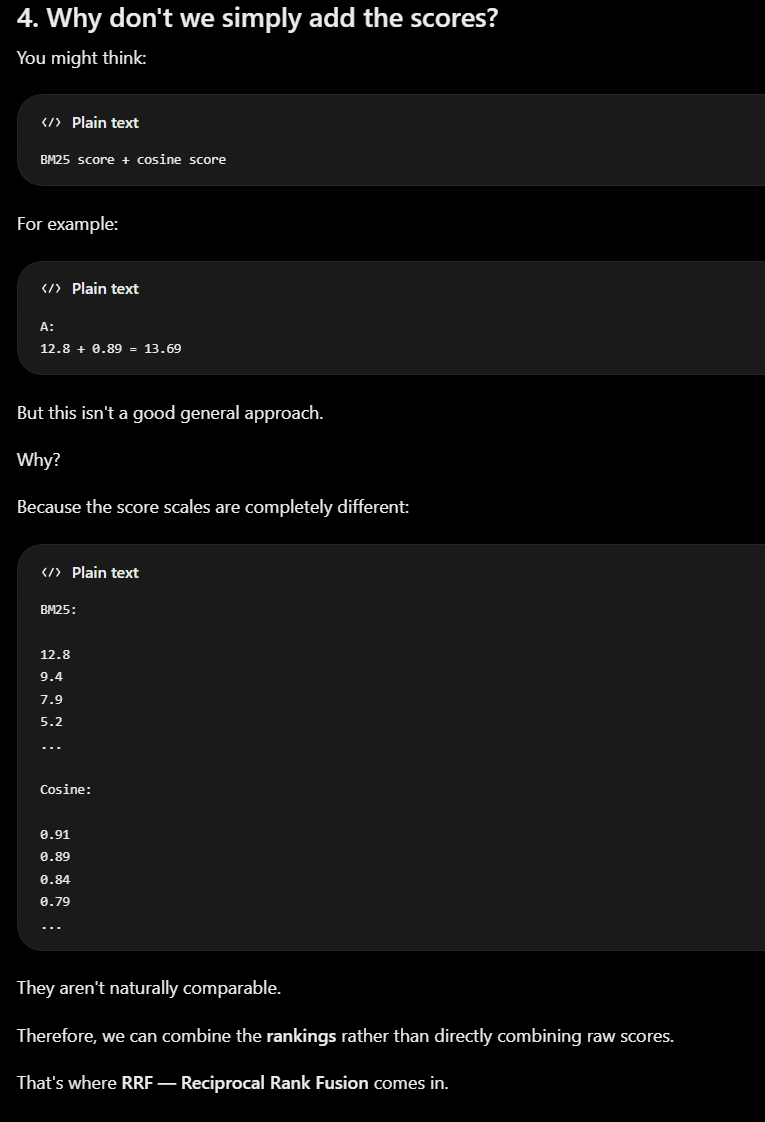

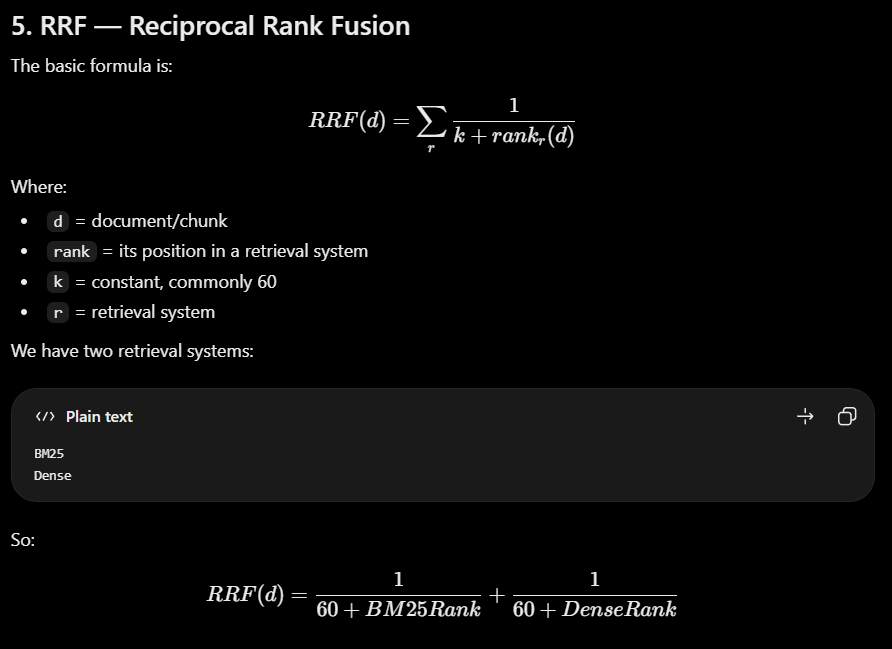

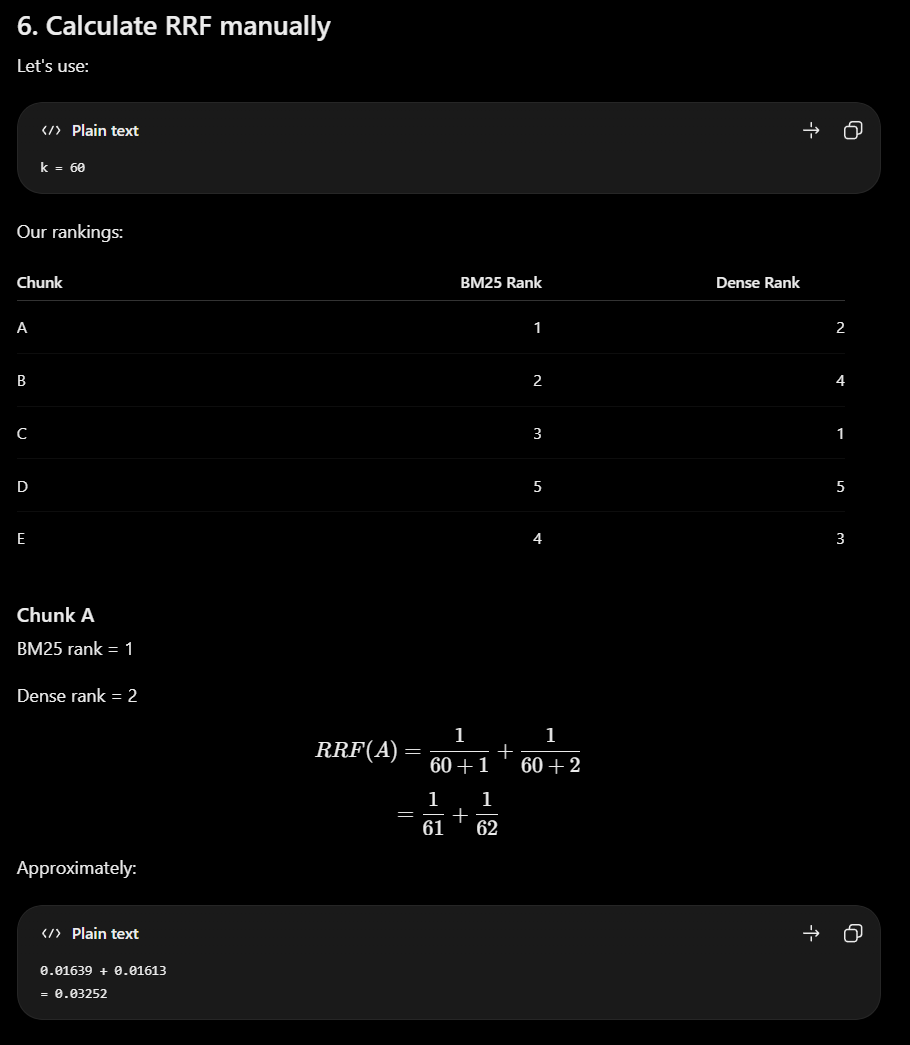

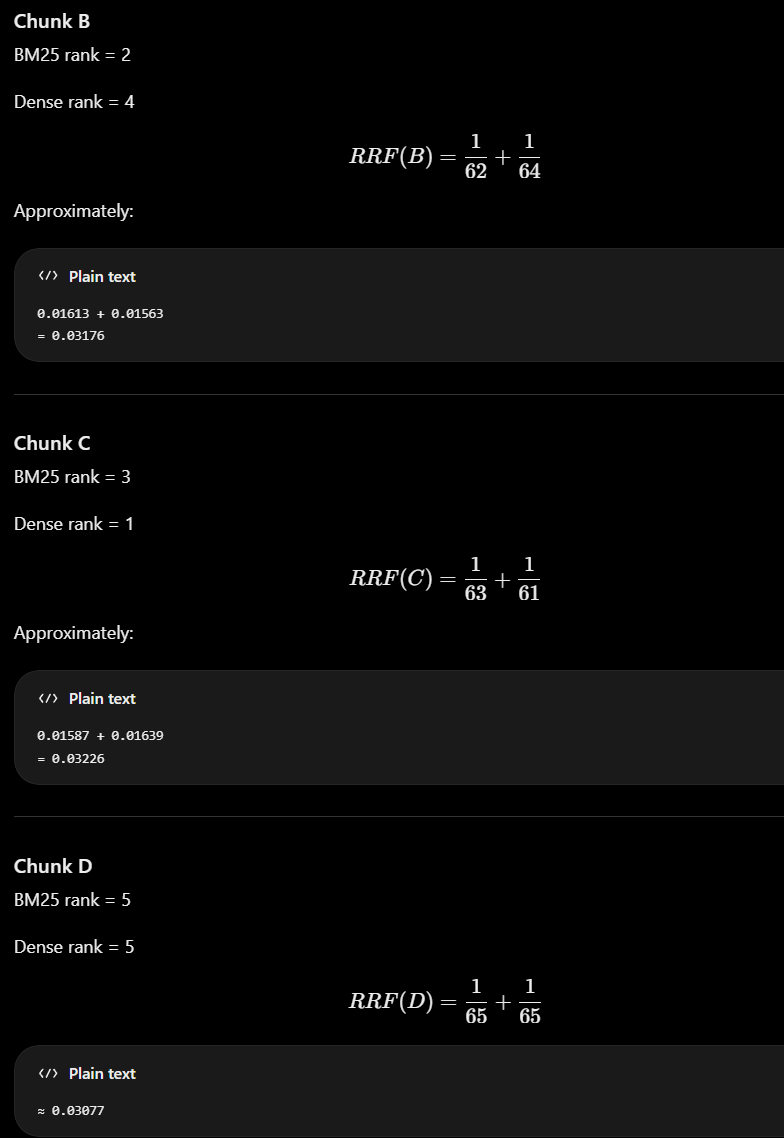

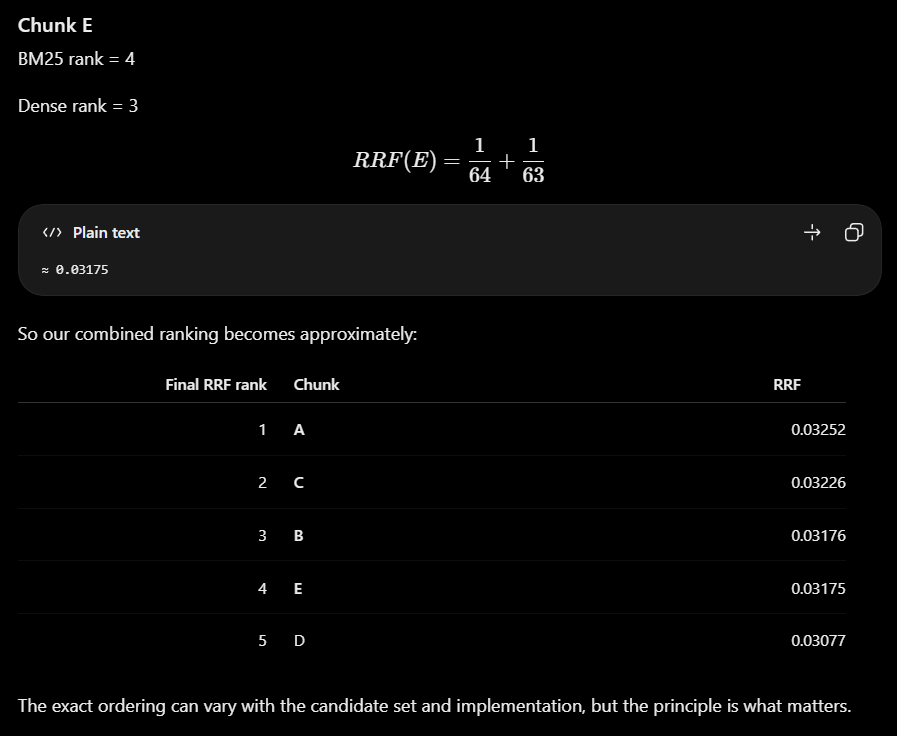

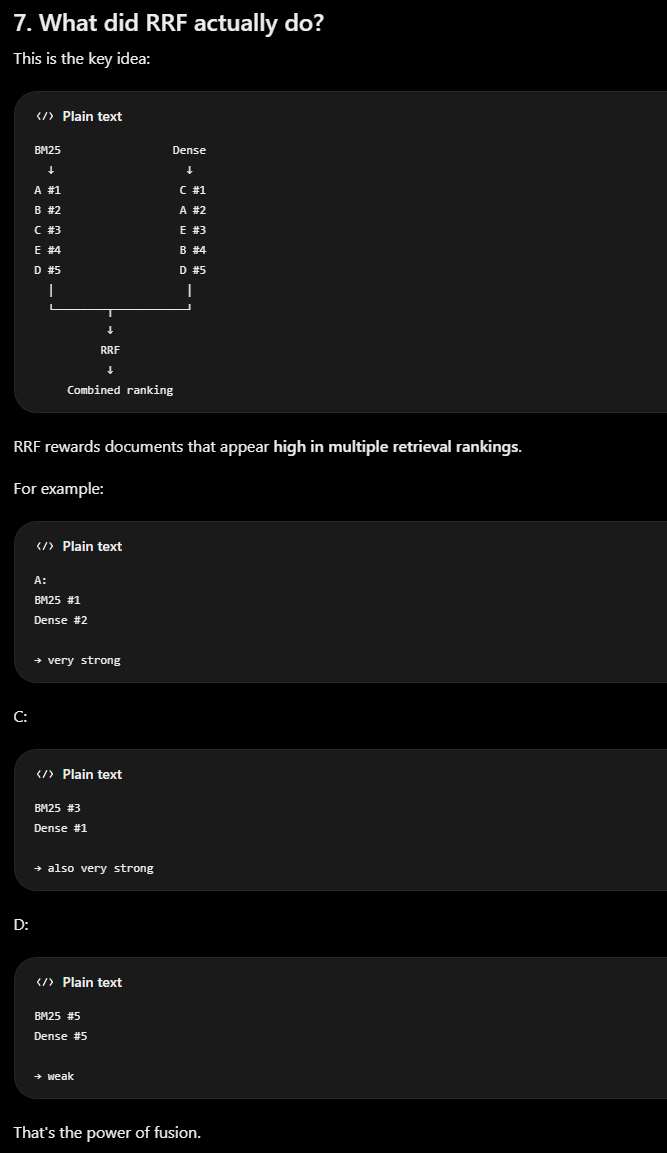

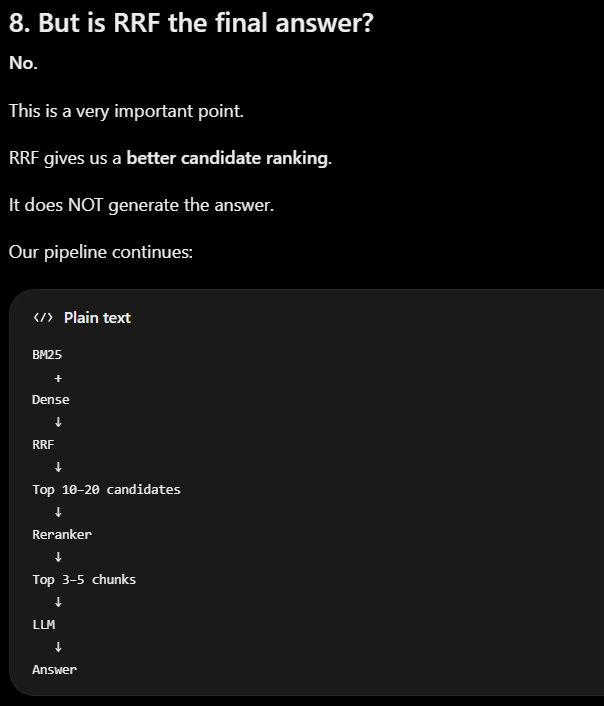

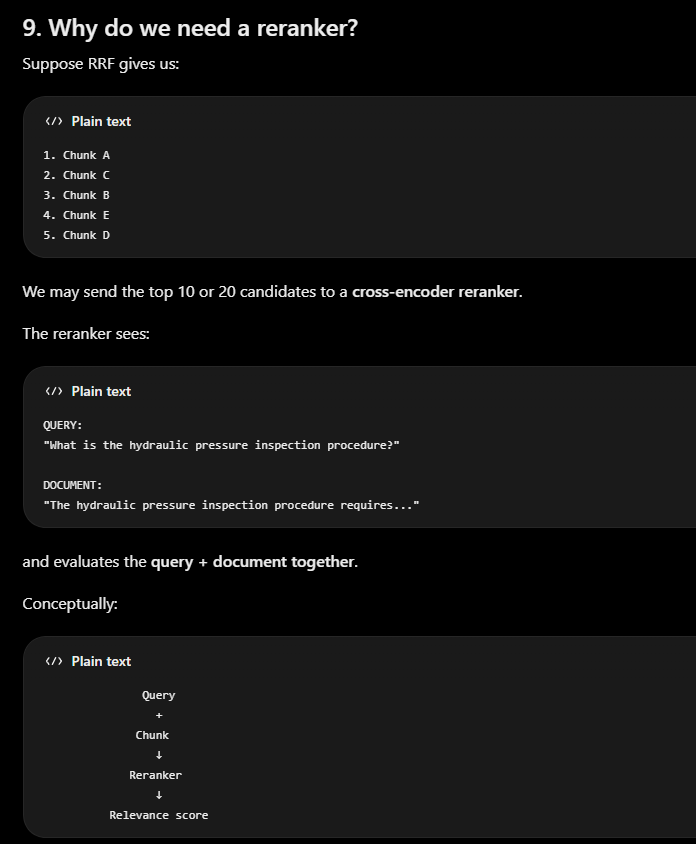

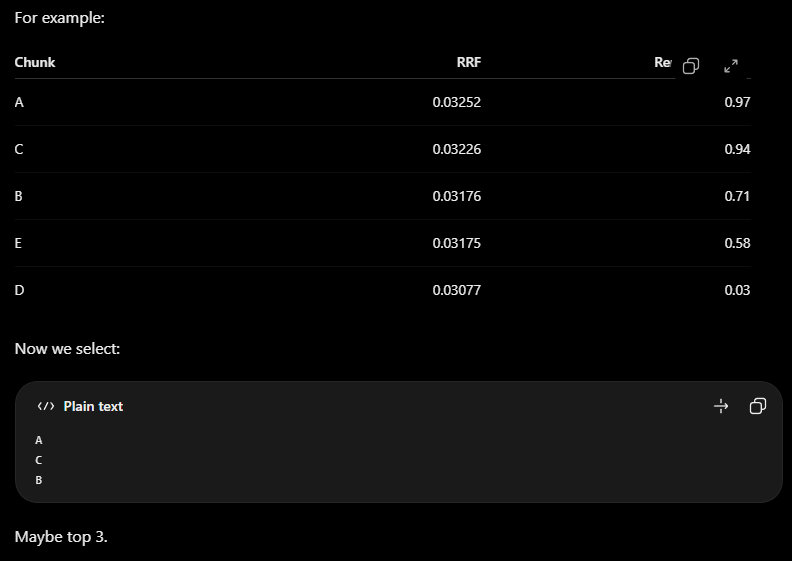

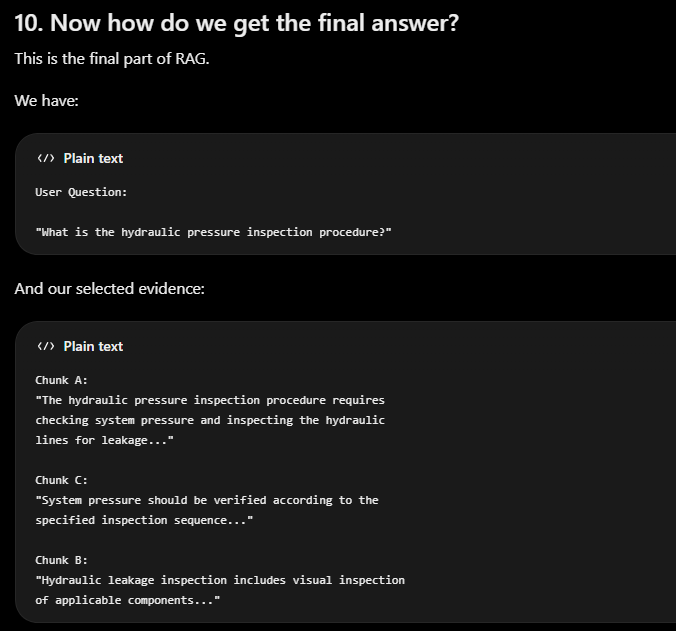

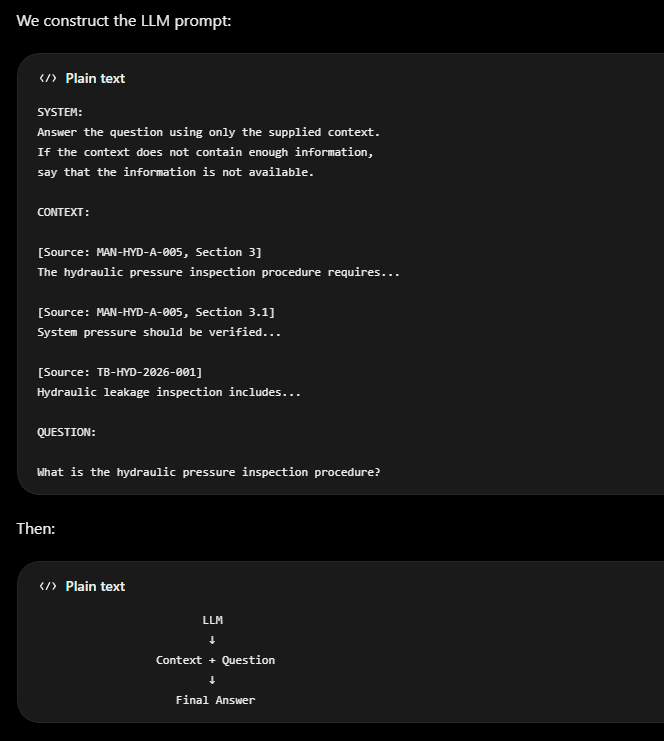

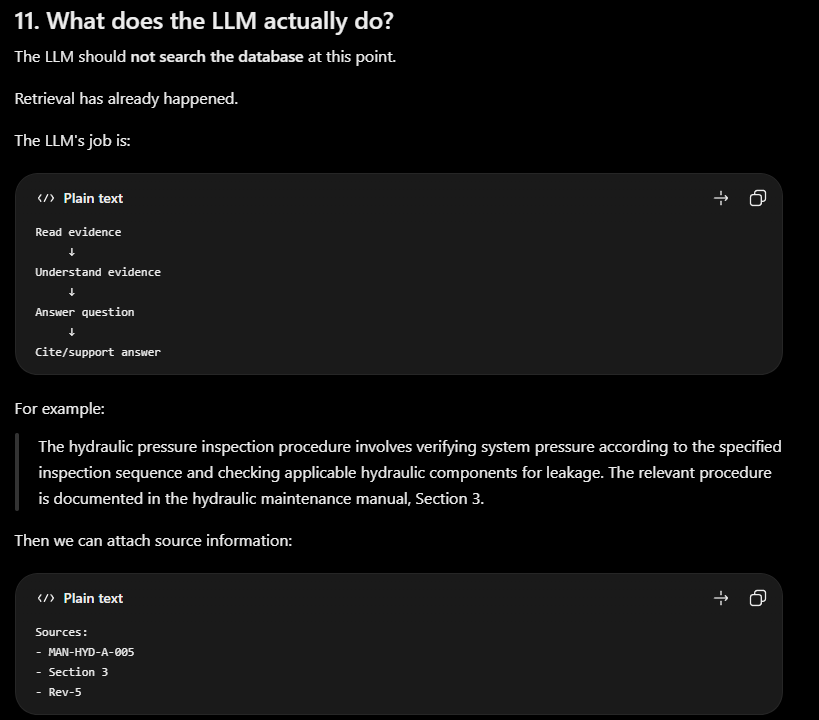

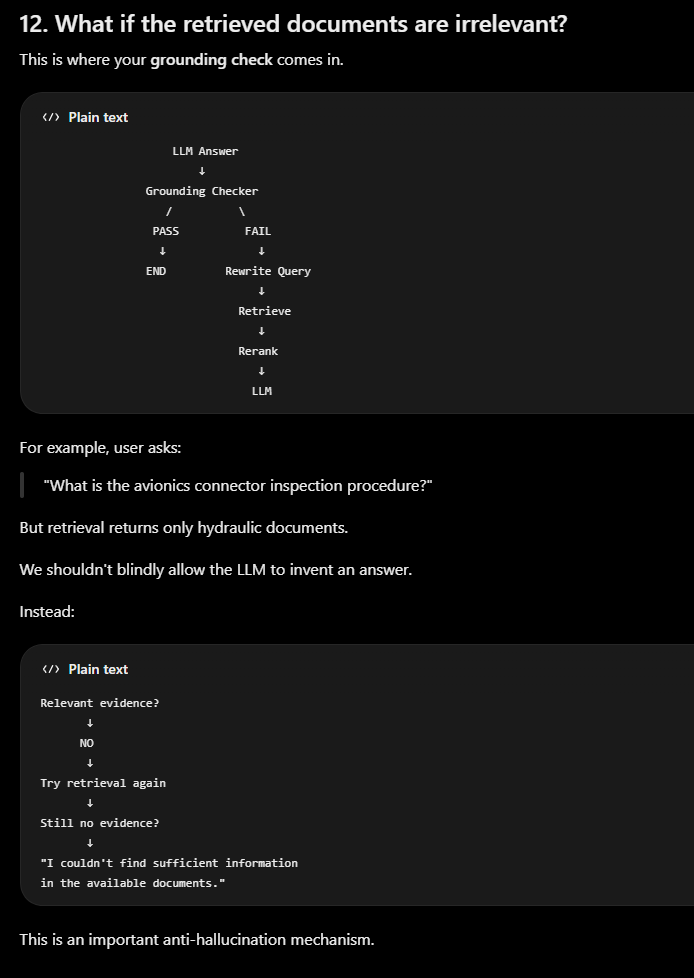

#### 13. Complete mathematics-to-answer flow
Now put everything together:

```
USER QUESTION
     │
     │ "What is hydraulic pressure inspection?"
     ▼
 ┌─────────────┐
 │   BM25      │
 │ Elasticsearch│
 └──────┬──────┘
        │
        │ lexical ranking
        ▼
   BM25 Results
        │
        │
        │              BGE-M3
        │                 │
        │                 ▼
        │             Query Vector
        │                 │
        │                 ▼
        │              Qdrant
        │                 │
        │                 ▼
        │            Dense Results
        │                 │
        └────────┬────────┘
                 ▼
            RRF Fusion
                 │
                 │ rank-based
                 │ combination
                 ▼
          Top 10–20 candidates
                 │
                 ▼
             Reranker
                 │
                 │ query-document
                 │ relevance
                 ▼
             Top 3–5
                 │
                 ▼
          Context Builder
                 │
                 ▼
            Prompt + Context
                 │
                 ▼
                LLM
                 │
                 ▼
             Answer
                 │
                 ▼
          Grounding Check
             /       \
           PASS       FAIL
            ↓           ↓
           END       Re-retrieve
```

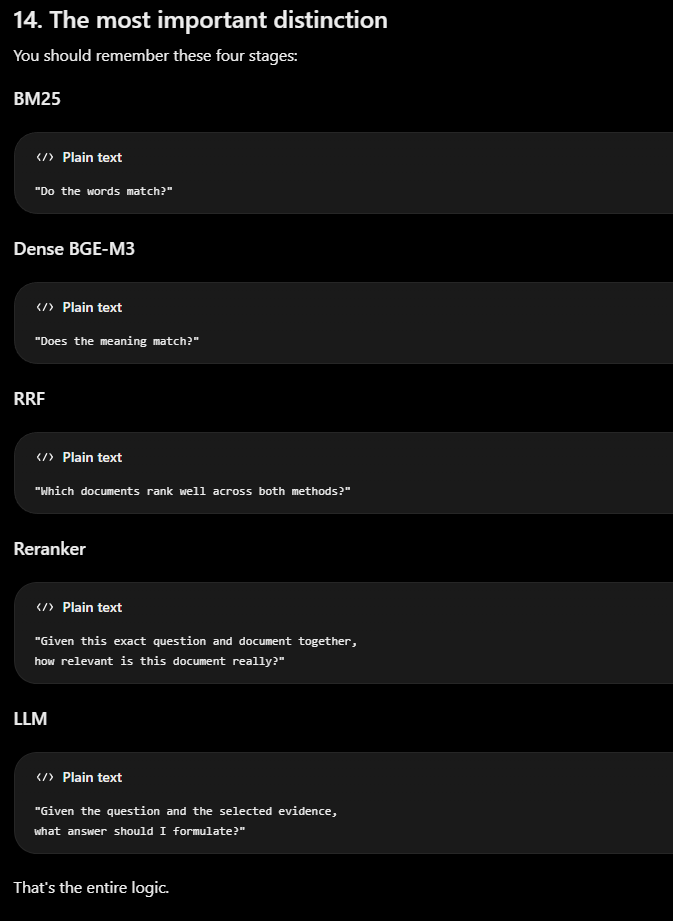

In [ ]:
response = es.search(
    index=INDEX_NAME,
    query={
        "bool": {
            "must": [
                {
                    "match": {
                        "text": "hydraulic technical bulletin"
                    }
                }
            ],
            "filter": [
                {
                    "term": {
                        "system": "hydraulic"
                    }
                },
                {
                    "term": {
                        "source_type": "bulletins"
                    }
                }
            ]
        }
    },
    size=5
)

In [ ]:
response

ObjectApiResponse({'took': 7, 'timed_out': False, '_shards': {'total': 6, 'successful': 6, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 0, 'relation': 'eq'}, 'max_score': None, 'hits': []}})

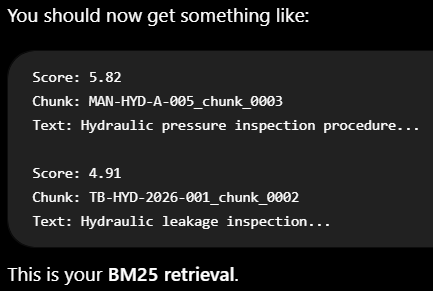

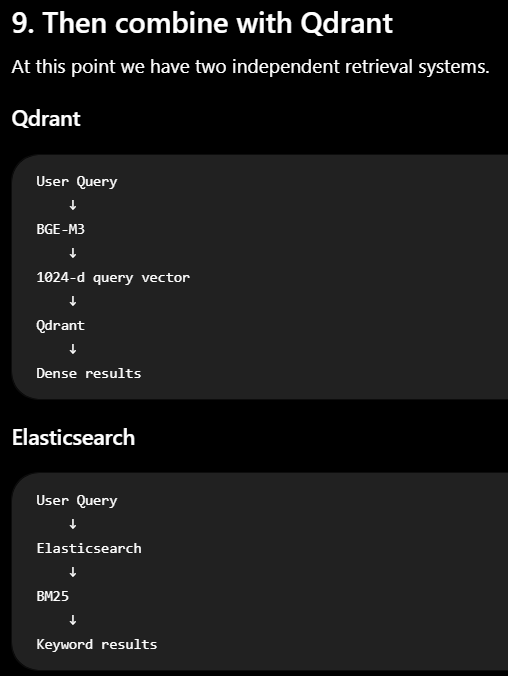

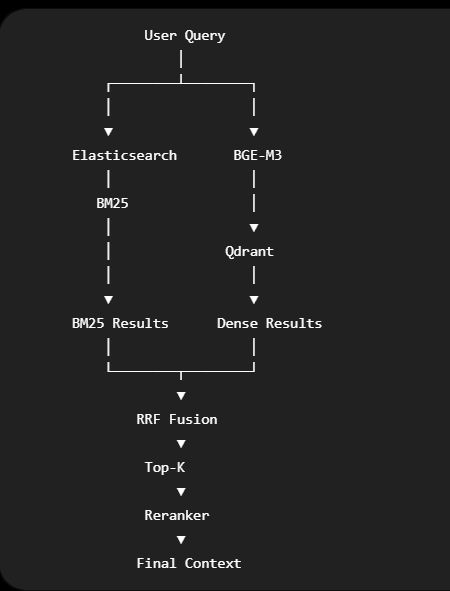

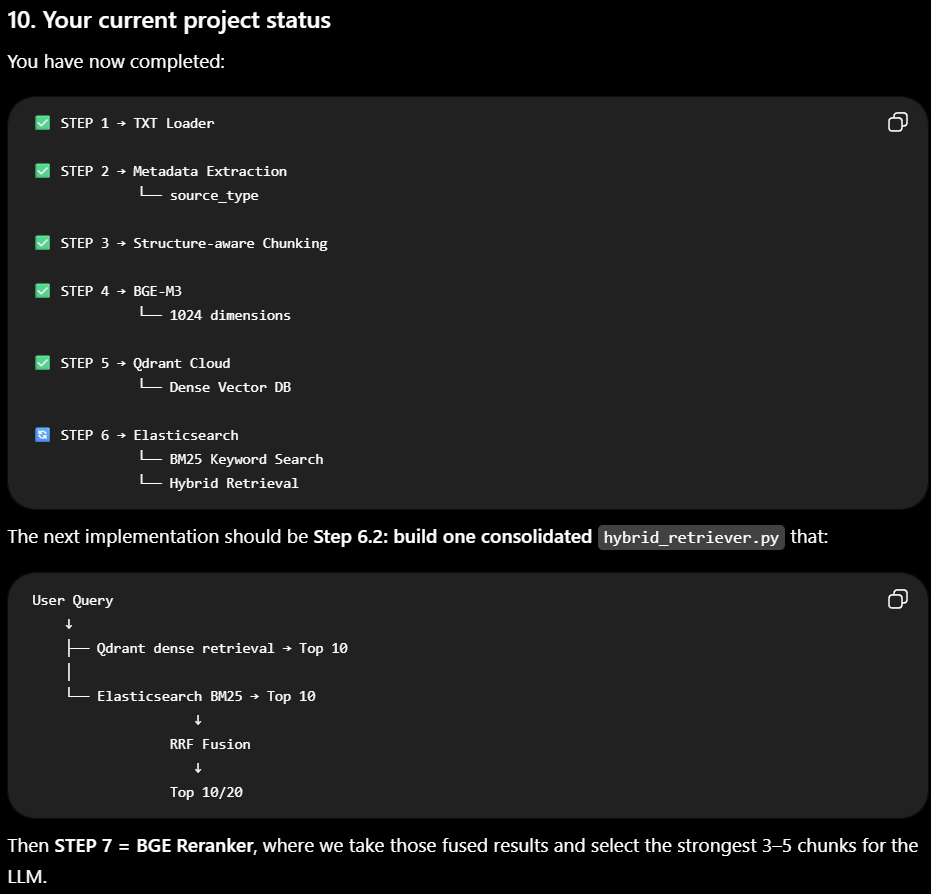

### Reranker (Hybrid Retrieval + RRF)

pipeline as of now:

```
User Query
    │
    ├───────────────┐
    ▼               ▼
 Elasticsearch     BGE-M3
    │               │
   BM25           Qdrant
    │               │
    └───────┬───────┘
            ▼
        RRF Fusion
            │
            ▼
      Top 10–20 chunks
            │
            ▼
       STEP 7 RERANKER
            │
            ▼
       Top 3–5 chunks
            │
            ▼
           LLM
```

The important question is:

**Why do we need another model after RRF?**

Because RRF only combines rankings. It does not deeply understand whether a particular chunk actually answers the question.

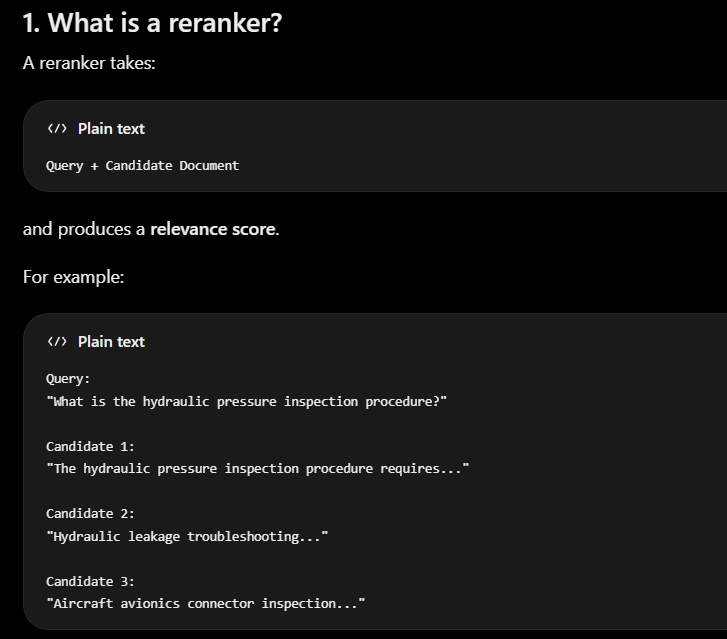

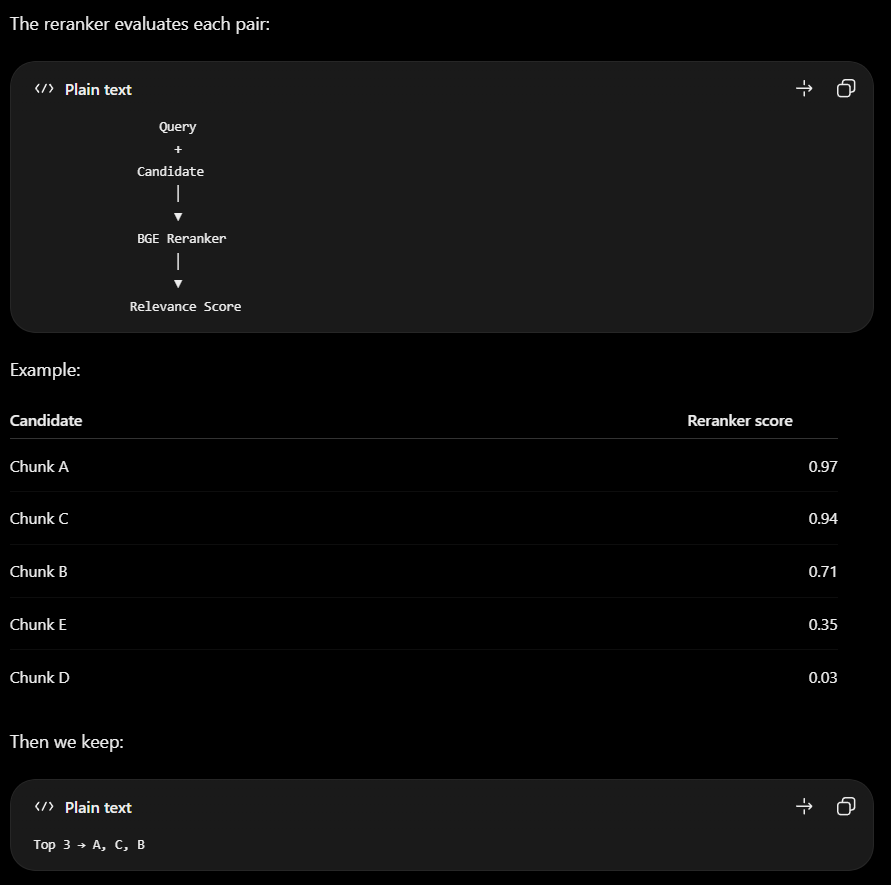

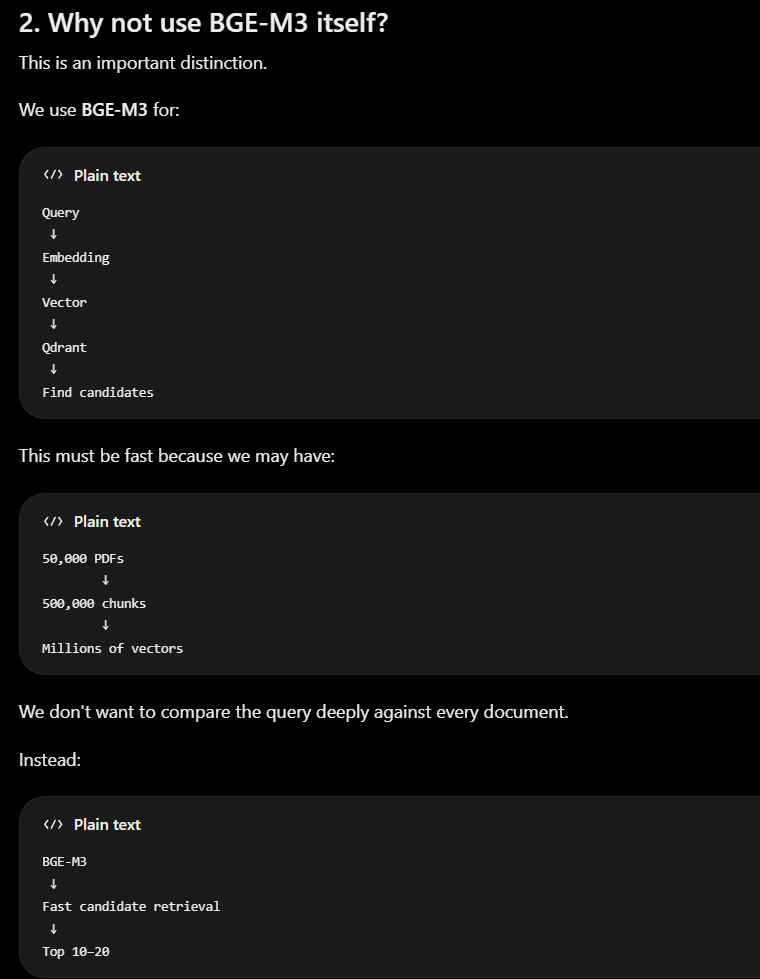

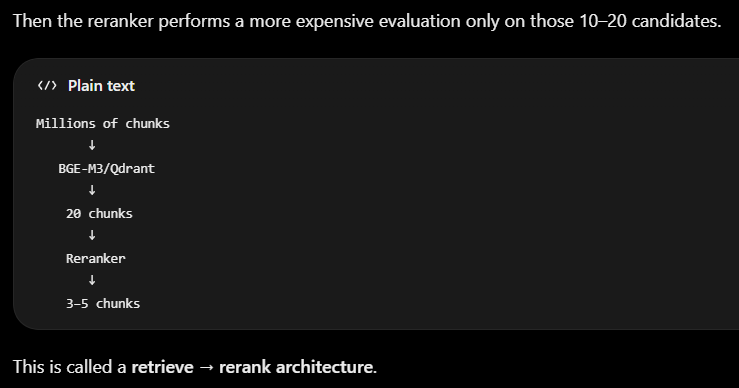

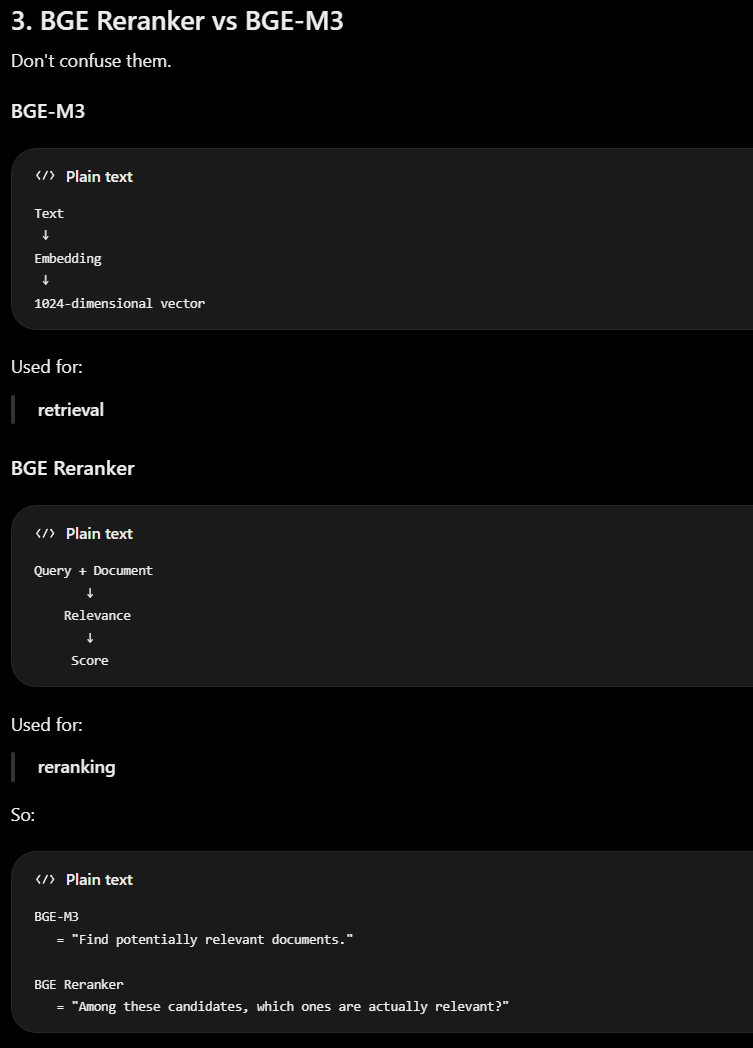

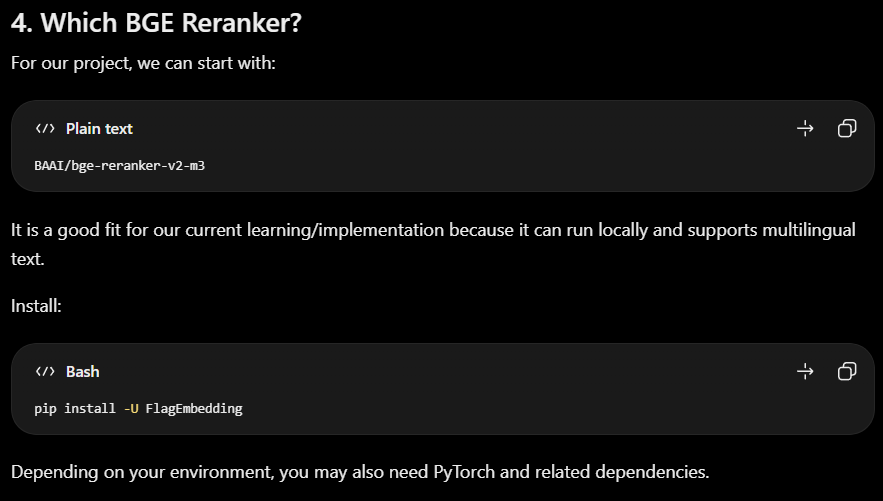


### 5. Basic reranker example

<!-- pip install -U huggingface_hub -->

In [104]:
from FlagEmbedding import FlagReranker

In [105]:
reranker = FlagReranker(
    "BAAI/bge-reranker-v2-m3",
    use_fp16=True
)

Now suppose RRF gave us:

In [106]:
query = "What is the hydraulic pressure inspection procedure?"

In [107]:
candidate_chunks = [
    "The hydraulic pressure inspection procedure requires checking system pressure...",
    "Hydraulic leakage troubleshooting includes visual inspection...",
    "Aircraft avionics connector inspection procedure...",
    "Hydraulic maintenance overview...",
]

In [108]:
pairs = [
    [query, chunk]
    for chunk in candidate_chunks
]

In [111]:
pairs

[['What is the hydraulic pressure inspection procedure?',
  'The hydraulic pressure inspection procedure requires checking system pressure...'],
 ['What is the hydraulic pressure inspection procedure?',
  'Hydraulic leakage troubleshooting includes visual inspection...'],
 ['What is the hydraulic pressure inspection procedure?',
  'Aircraft avionics connector inspection procedure...'],
 ['What is the hydraulic pressure inspection procedure?',
  'Hydraulic maintenance overview...']]

In [110]:
scores = reranker.compute_score(
    pairs,
    normalize=True
)

In [112]:
for chunk, score in zip(candidate_chunks, scores):
    print("Score:", score)
    print("Text:", chunk)
    print("-" * 80)

Score: 0.990171489857036
Text: The hydraulic pressure inspection procedure requires checking system pressure...
--------------------------------------------------------------------------------
Score: 0.04539726698878882
Text: Hydraulic leakage troubleshooting includes visual inspection...
--------------------------------------------------------------------------------
Score: 0.0026153739216370395
Text: Aircraft avionics connector inspection procedure...
--------------------------------------------------------------------------------
Score: 0.010650963126704435
Text: Hydraulic maintenance overview...
--------------------------------------------------------------------------------


The actual numbers will depend on the model and inputs.

#### 6. Our actual pipeline

We don't want to rerank arbitrary chunks.

We start with the RRF results.

Ex:
```


```

In [113]:
rrf_results = [
    {
        "chunk_id": "A",
        "text": "Hydraulic pressure inspection procedure..."
    },
    {
        "chunk_id": "C",
        "text": "Procedure for verifying system pressure..."
    },
    {
        "chunk_id": "B",
        "text": "Hydraulic leakage troubleshooting..."
    },
    {
        "chunk_id": "E",
        "text": "Hydraulic maintenance overview..."
    },
    {
        "chunk_id": "D",
        "text": "Avionics connector inspection..."
    }
]

In [114]:
pairs = [
    [query, item["text"]]
    for item in rrf_results
]

In [115]:
scores = reranker.compute_score(
    pairs,
    normalize=True
)

In [116]:
for item, score in zip(rrf_results, scores):
    item["reranker_score"] = float(score)

In [117]:
reranked_results = sorted(
    rrf_results,
    key=lambda x: x["reranker_score"],
    reverse=True
)

In [119]:
top_chunks = reranked_results[:3]
top_chunks

[{'chunk_id': 'A',
  'text': 'Hydraulic pressure inspection procedure...',
  'reranker_score': 0.9994911227212272},
 {'chunk_id': 'C',
  'text': 'Procedure for verifying system pressure...',
  'reranker_score': 0.1887459096174466},
 {'chunk_id': 'E',
  'text': 'Hydraulic maintenance overview...',
  'reranker_score': 0.010650963126704435}]

```
RRF Top 10–20
       ↓
BGE Reranker
       ↓
Top 3–5
```

#### 7. Why only 3-5 chunks?
Because we don't want to dump everything into the LLM.

Suppose RRF give us:

```
20 chunks
×
1000 characters
```

That's potentially a lot of irrelevant context.

Instead:
```
20 candidates
       ↓
Reranker
       ↓
3–5 highly relevant chunks
       ↓
LLM
```

Benefits:
- Less irrelevant context
- Lower token usage
- Lower latency
- Less noise
- Better answer grounding
- Lower chance of confusing the LLM

But **3-5 is not a universal rule.** The actual number should be tuned using evaluation data. A complex question may need more context, a simple question may need only 2-3 chunks.

#### 8. Where does the final answer come from?
This is the complete chain:
```
                    USER
                     │
                     ▼
       "What is hydraulic pressure
          inspection procedure?"
                     │
             ┌───────┴───────┐
             ▼               ▼
          BM25             BGE-M3
             │               │
             ▼               ▼
      Elasticsearch        Qdrant
             │               │
             └───────┬───────┘
                     ▼
                 RRF Fusion
                     │
                     ▼
                Top 20 chunks
                     │
                     ▼
              BGE Reranker
                     │
                     ▼
                Top 3 chunks
                     │
                     ▼
             Context Builder
                     │
                     ▼
                  Prompt
                     │
                     ▼
                    LLM
                     │
                     ▼
              Final Answer
```

#### 9. The LLM does Not see the other 17 chunks?
This is very important.

Suppose:
```
RRF
 ↓
20 chunks
```

After reranking
```
Top 3

Chunk A
Chunk C
Chunk B
```

The LLM receives only:
```
SYSTEM:
Answer using only the supplied evidence.

CONTEXT:

[Chunk A]
...

[Chunk C]
...

[Chunk B]
...

QUESTION:
What is the hydraulic pressure inspection procedure?
```

Then the LLM generates the answer.

#### 10. Add source information
We should preserve metadataa throughout the entire pipeline.

Ex:
```
{
    "chunk_id": "MAN-HYD-A-005_chunk_0003",

    "text": "...",

    "document_id": "MAN-HYD-A-005",

    "document_type": "maintenance_manual",

    "title": "Aircraft-A Hydraulic System Maintenance Manual",

    "revision": "Rev-5",

    "system": "hydraulic",

    "section": "SECTION 3: PRESSURE INSPECTION",

    "source_type": "manuals",

    "reranker_score": 0.97
}
```

Then our final answer can say:
The hydraulic pressure inspection procedure requires verification of system pressure according to the specified inspection sequence.  
Source: MAN-HYD-A-005, Rev-5, Section 3.

This is much better than giving the user an unsupported answer.


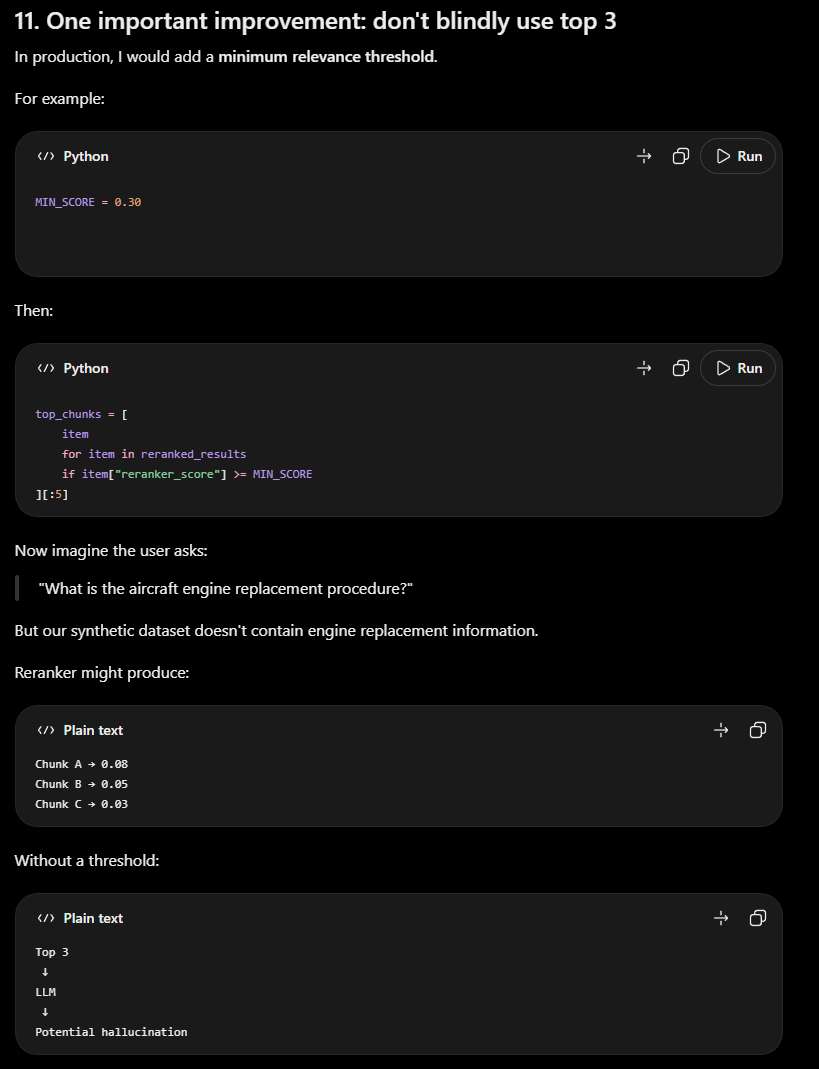

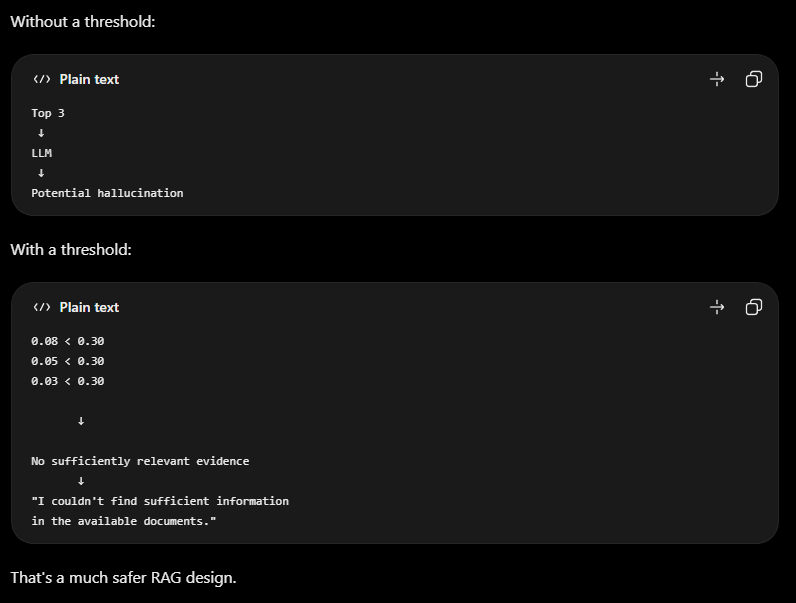

Your RAG system now looks like:

```
                    USER QUERY
                        │
            ┌───────────┴───────────┐
            │                       │
            ▼                       ▼
      Elasticsearch              BGE-M3
          BM25                     │
            │                      ▼
            │                   Qdrant
            │                      │
            ▼                      ▼
       BM25 Top-10             Dense Top-10
            │                      │
            └──────────┬───────────┘
                       ▼
                  RRF Fusion
                       │
                       ▼
                 Top 10–20
                       │
                       ▼
             BGE Reranker v2-M3
                       │
                       ▼
                  Score each
                       │
                       ▼
              Sort by relevance
                       │
                       ▼
                Threshold check
                   /       \
                 PASS       FAIL
                  │           │
                  ▼           ▼
               Top 3–5     Abstain/
                  │         Retry
                  ▼
             Context Builder
                  │
                  ▼
                  LLM
                  │
                  ▼
           Grounding Validation
                  │
                  ▼
             Final Answer
```

Model Mental Tips:
```
Qdrant/BGE-M3
      ↓
"Find candidates"

RRF
      ↓
"Combine candidates"

BGE Reranker
      ↓
"Pick the best evidence"

LLM
      ↓
"Write the answer"

Grounding Check
      ↓
"Is the answer supported?"
```